# 🔮 Advanced Predictive Maintenance - Model Training

This notebook trains advanced machine learning models for fiber maintenance predictions. The trained models will be saved to the `models/` folder and used by the Advanced Predictions dashboard.

## Prediction Targets:
1. **SLA Breach Prediction** - Will a ticket breach SLA? (Classification)
2. **MTTR Prediction** - How long will resolution take? (Regression)
3. **Ticket Volume Prediction** - Daily/weekly ticket counts (Time Series)
4. **Cluster Workload Prediction** - Which clusters need attention? (Regression)
5. **Fault Category Prediction** - What type of fault is it? (Multi-class)

## Models Used:
- XGBoost, LightGBM, CatBoost
- Random Forest, Gradient Boosting
- Neural Networks (MLP)

**Important:** We exclude ALARM tickets and focus on real FAULT tickets only.

## 1. Import Required Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Database
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('dark_background')

# Sklearn - Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Sklearn - Models
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression, Ridge, Lasso

# Sklearn - Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

# Advanced Models
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
    print("✓ XGBoost available")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("✗ XGBoost not available - install with: pip install xgboost")

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
    print("✓ LightGBM available")
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("✗ LightGBM not available - install with: pip install lightgbm")

try:
    from catboost import CatBoostClassifier, CatBoostRegressor
    CATBOOST_AVAILABLE = True
    print("✓ CatBoost available")
except ImportError:
    CATBOOST_AVAILABLE = False
    print("✗ CatBoost not available - install with: pip install catboost")

# Model persistence
import joblib
import json

# Load environment variables
load_dotenv()

print("\n✓ All core libraries imported successfully!")

✓ XGBoost available
✓ LightGBM available
✗ CatBoost not available - install with: pip install catboost

✓ All core libraries imported successfully!


## 2. Load Data from Database

Load all historical ticket data, excluding alarms. We'll use the same connection approach from the data exploration notebook.

In [ ]:
# Database connection settings - Using Local Server (config 2)
config_number = 1

DB_NAME = os.getenv(f'DB_NAME_{config_number}', 'fiber_maintainance_department')
DB_HOST = os.getenv(f'DB_HOST_{config_number}', 'localhost')
DB_USER = os.getenv(f'DB_USER_{config_number}', 'root')
DB_PASSWORD = os.getenv(f'DB_PASSWORD_{config_number}', '')

print(f"Connecting to: {DB_HOST}/{DB_NAME}")

# Create database connection
try:
    engine = create_engine(f'mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}@{DB_HOST}/{DB_NAME}')

    # Load ALL data for model training (we need as much data as possible)
    query = """
    SELECT * FROM engineered_tickets
    ORDER BY ESCALATED_TIME
    """
    df_raw = pd.read_sql(query, engine)
    print(f"✓ Loaded {len(df_raw):,} records from the last 12 months")

except Exception as e:
    print(f"✗ Error connecting to database: {e}")
    print("Please check your .env file and database credentials")

Connecting to: localhost/fiber_maintainance_department
✗ Error connecting to database: No module named 'mysql'
Please check your .env file and database credentials


In [ ]:
df_raw.to_excel(r'C:\Users\Sys_Admin\Documents\Work\DEPARTMENTS\FIBER MAINTAINANCE DEPARTMENT\FIber maintainance analytics sytem\fiber_app\engineered_tickets_full_data.xlsx', index=False)

NameError: name 'df_raw' is not defined

In [2]:
df_raw=pd.read_excel('/content/engineered_tickets_full_data.xlsx')

In [3]:
df_raw

,INC,ACCESS_GRANTED_TIME,ACCESS_PROVIDER,ACCESS_REQUEST_TIME,ACCESS_SITE,CLEARS,DISPATCHER,ENGINEER1,ENGINEER2,ENGINEER3,...,PATROL,CAUSE,CHALLENGE,EXTERNAL_SLA,EXTERNAL_BREACHED_HOURS,EXTERNAL_BREACHED,INHOUSE_SLA,INHOUSE_BREACHED_HOURS,INHOUSE_BREACHED,DURATION
0,INC000010340145,NaT,NaN,NaT,NaN,"CORE PROVISIONING DONE, SPLICING DONE IN 6 JOI...",NaN,ERIC OMONDI,NaN,NaN,...,NaN,CORE PROVISIONING,NaN,24.0,29.03860,YES,12.0,41.03860,YES,53:02:19
1,INC000010346336,NaT,NaN,NaT,NaN,TEAM RESPLICED CORE 10 AT THE ENTRY MH AT NGOM...,NaN,ERIC OMONDI,NaN,NaN,...,NaN,CORE BREAK,ACCESS DELAY,4.0,1.96361,YES,2.0,3.96361,YES,05:57:49
2,INC000010357554,NaT,NaN,NaT,NaN,POWER FAILURE,PASCAL,ERIC OMONDI,NaN,NaN,...,NaN,POWER ISSUE,NaN,NaN,NaN,NO,NaN,NaN,NO,01:13:36
3,INC000010373107,NaT,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,UNCLASSIFIED,NaN,4.0,21.65310,YES,2.0,23.65310,YES,25:39:11
4,INC000010379033,NaT,NaN,NaT,NaN,CLEARS; TEAM SWAPPED CORE 9 TUBE 4 TO TUBE 8 C...,PASCAL,ERIC OMONDI,NaN,NaN,...,NaN,CORE FAILING MIDSPAN,ACCESS DELAY,4.0,28.04890,YES,2.0,30.04890,YES,32:02:56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60717,INC000028219164,2025-11-28 18:31:00,RILEY FALCON,2025-11-28 18:31:00,NaN,"TEAM RESPLICED BROKEN CORES T2 C1,2\n",DENIS,ANDREW MAKANDA,CHRISPUS KARANI,NaN,...,NaN,DISTURBED/TAMPERING,NaN,4.0,NaN,NO,2.0,NaN,NO,00:30:12
60718,INC000028219358,NaT,NaN,NaT,NaN,"UPTIME CONFIRMED, LINK AUTO RESOLVED.",PASCAL,ANDREW MAKANDA,CHRISPUS KARANI,NaN,...,NaN,ALARM,NaN,4.0,NaN,NO,2.0,NaN,NO,00:05:38
60719,INC000028213540,NaT,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,FAULTY CONNECTOR,NaN,4.0,NaN,NO,2.0,NaN,NO,01:21:56
60720,INC000028219290,NaT,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,ALARM,NaN,4.0,NaN,NO,2.0,NaN,NO,01:26:29


In [4]:
# Filter out ALARM tickets - focus on real FAULT tickets only
print("=" * 60)
print("FILTERING DATA: Removing Alarm Tickets")
print("=" * 60)

# Identify alarm tickets based on CAUSE column
ALARM_KEYWORDS = ['ALARM', 'NMS ALARM', 'SYSTEM ALARM', 'AUTO ALARM']

# Create IS_ALARM flag
df_raw['IS_ALARM'] = False
if 'CAUSE' in df_raw.columns:
    df_raw['IS_ALARM'] = df_raw['CAUSE'].astype(str).str.upper().str.contains('ALARM', na=False)

# Also check ROOT_CAUSE
ALARM_ROOT_CAUSES = ['BATTERY ALARM', 'POWER ALARM', 'TEMPERATURE ALARM', 'DOOR ALARM']
if 'ROOT_CAUSE' in df_raw.columns:
    df_raw['IS_ALARM'] = df_raw['IS_ALARM'] | df_raw['ROOT_CAUSE'].isin(ALARM_ROOT_CAUSES)

# Count alarms vs faults
total_records = len(df_raw)
alarm_count = df_raw['IS_ALARM'].sum()
fault_count = total_records - alarm_count

print(f"Total records: {total_records:,}")
print(f"Alarm tickets: {alarm_count:,} ({alarm_count/total_records*100:.1f}%)")
print(f"Fault tickets: {fault_count:,} ({fault_count/total_records*100:.1f}%)")

# Keep only fault tickets
df = df_raw[~df_raw['IS_ALARM']].copy()
print(f"\n✓ Using {len(df):,} FAULT tickets for model training")

FILTERING DATA: Removing Alarm Tickets
Total records: 60,722
Alarm tickets: 37,720 (62.1%)
Fault tickets: 23,002 (37.9%)

✓ Using 23,002 FAULT tickets for model training


In [5]:
# Quick data overview
print("=" * 60)
print("DATA OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"\nColumns ({len(df.columns)}):")
print(df.columns.tolist())
print(f"\nData types:")
print(df.dtypes.value_counts())

DATA OVERVIEW
Shape: (23002, 42)

Columns (42):
['INC', 'ACCESS_GRANTED_TIME', 'ACCESS_PROVIDER', 'ACCESS_REQUEST_TIME', 'ACCESS_SITE', 'CLEARS', 'DISPATCHER', 'ENGINEER1', 'ENGINEER2', 'ENGINEER3', 'ESCALATED_TIME', 'LATITUDE', 'LINK_DESCRIPTION', 'LONGITUDE', 'MATERIAL_USED', 'REGION', 'ROOT_CAUSE', 'SECURITY_ARRIVAL_TIME', 'SECURITY_REQUEST_TIME', 'SERVICE', 'SOURCE_FILE', 'STATUS', 'UPTIME', 'CAUSE_OF_FAILURE', 'CITY', 'SITE_ID', 'SITE_NAME', 'NOTES', 'SUMMARY', 'ESCALATED_DAY', 'CLUSTER', 'PATROL', 'CAUSE', 'CHALLENGE', 'EXTERNAL_SLA', 'EXTERNAL_BREACHED_HOURS', 'EXTERNAL_BREACHED', 'INHOUSE_SLA', 'INHOUSE_BREACHED_HOURS', 'INHOUSE_BREACHED', 'DURATION', 'IS_ALARM']

Data types:
object            28
float64            7
datetime64[ns]     6
bool               1
Name: count, dtype: int64


## 3. Feature Engineering

Create meaningful features for our prediction models:
- **Temporal features**: Hour, day of week, month, is_weekend
- **Historical features**: Rolling averages, lag features
- **Categorical encoding**: Cluster, Region, Service type
- **Target variables**: SLA breach, MTTR, Fault category

In [6]:
def engineer_features(df):
    """
    Create features for machine learning models.
    """
    df = df.copy()

    print("Engineering features...")

    # ============ DATETIME FEATURES ============
    if 'ESCALATED_TIME' in df.columns:
        df['ESCALATED_TIME'] = pd.to_datetime(df['ESCALATED_TIME'], errors='coerce')
        df['HOUR'] = df['ESCALATED_TIME'].dt.hour
        df['DAY_OF_WEEK'] = df['ESCALATED_TIME'].dt.dayofweek  # 0=Monday
        df['DAY_OF_MONTH'] = df['ESCALATED_TIME'].dt.day
        df['MONTH'] = df['ESCALATED_TIME'].dt.month
        df['WEEK_OF_YEAR'] = df['ESCALATED_TIME'].dt.isocalendar().week.astype(int)
        df['IS_WEEKEND'] = df['DAY_OF_WEEK'].isin([5, 6]).astype(int)
        df['IS_NIGHT'] = df['HOUR'].apply(lambda x: 1 if x < 6 or x >= 22 else 0)
        df['IS_BUSINESS_HOURS'] = df['HOUR'].apply(lambda x: 1 if 8 <= x <= 17 else 0)
        df['DATE'] = df['ESCALATED_TIME'].dt.date
        print("  ✓ Datetime features created")

    # ============ DURATION/MTTR FEATURES ============
    if 'DURATION' in df.columns:
        def duration_to_minutes(duration_str):
            try:
                if pd.isna(duration_str):
                    return None
                parts = str(duration_str).split(':')
                if len(parts) == 3:
                    return int(parts[0]) * 60 + int(parts[1]) + int(parts[2]) / 60
                return None
            except:
                return None

        df['MTTR_MINUTES'] = df['DURATION'].apply(duration_to_minutes)
        df['MTTR_HOURS'] = df['MTTR_MINUTES'] / 60

        # MTTR categories for classification
        df['MTTR_CATEGORY'] = pd.cut(
            df['MTTR_HOURS'],
            bins=[0, 2, 6, 12, 24, float('inf')],
            labels=['Quick (<2h)', 'Fast (2-6h)', 'Normal (6-12h)', 'Slow (12-24h)', 'Critical (>24h)']
        )
        print("  ✓ MTTR features created")

    # ============ SLA BREACH TARGET ============
    if 'EXTERNAL_BREACHED' in df.columns:
        df['SLA_BREACHED'] = df['EXTERNAL_BREACHED'].astype(str).str.upper().isin(['YES', 'TRUE', '1', 'Y']).astype(int)
        print("  ✓ SLA breach target created")

    # ============ CATEGORICAL ENCODING ============
    # Create label encoders for categorical columns
    categorical_cols = ['CLUSTER', 'REGION', 'SERVICE', 'CAUSE', 'DISPATCHER']
    label_encoders = {}

    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].fillna('UNKNOWN')
            le = LabelEncoder()
            df[f'{col}_ENCODED'] = le.fit_transform(df[col].astype(str))
            label_encoders[col] = le

    print("  ✓ Categorical encoding completed")

    return df, label_encoders

# Apply feature engineering
df_featured, label_encoders = engineer_features(df)
print(f"\n✓ Feature engineering complete. Shape: {df_featured.shape}")

Engineering features...
  ✓ Datetime features created
  ✓ MTTR features created
  ✓ SLA breach target created
  ✓ Categorical encoding completed

✓ Feature engineering complete. Shape: (23002, 60)


In [7]:
# Create historical/aggregate features per cluster
def create_cluster_features(df):
    """Create cluster-level features based on historical data."""
    df = df.copy()

    if 'CLUSTER' not in df.columns or 'DATE' not in df.columns:
        return df

    # Sort by date for proper rolling calculations
    df = df.sort_values('ESCALATED_TIME')

    # Daily ticket counts per cluster
    daily_cluster = df.groupby(['DATE', 'CLUSTER']).agg({
        'INC': 'count',
        'MTTR_MINUTES': 'mean',
        'SLA_BREACHED': 'mean'
    }).reset_index()
    daily_cluster.columns = ['DATE', 'CLUSTER', 'DAILY_TICKETS', 'DAILY_AVG_MTTR', 'DAILY_BREACH_RATE']

    # Merge back
    df = df.merge(daily_cluster, on=['DATE', 'CLUSTER'], how='left')

    # Calculate cluster-level historical averages
    cluster_stats = df.groupby('CLUSTER').agg({
        'MTTR_MINUTES': ['mean', 'std'],
        'SLA_BREACHED': 'mean',
        'INC': 'count'
    }).reset_index()
    cluster_stats.columns = ['CLUSTER', 'CLUSTER_AVG_MTTR', 'CLUSTER_STD_MTTR', 'CLUSTER_BREACH_RATE', 'CLUSTER_TOTAL_TICKETS']

    df = df.merge(cluster_stats, on='CLUSTER', how='left')

    print("  ✓ Cluster-level features created")
    return df

df_featured = create_cluster_features(df_featured)
print(f"\n✓ Total features: {df_featured.shape[1]}")

  ✓ Cluster-level features created

✓ Total features: 67


## 4. Exploratory Data Analysis

Visualize key patterns and relationships in the data before training models.

FileNotFoundError: [Errno 2] No such file or directory: 'models/eda_plots.png'

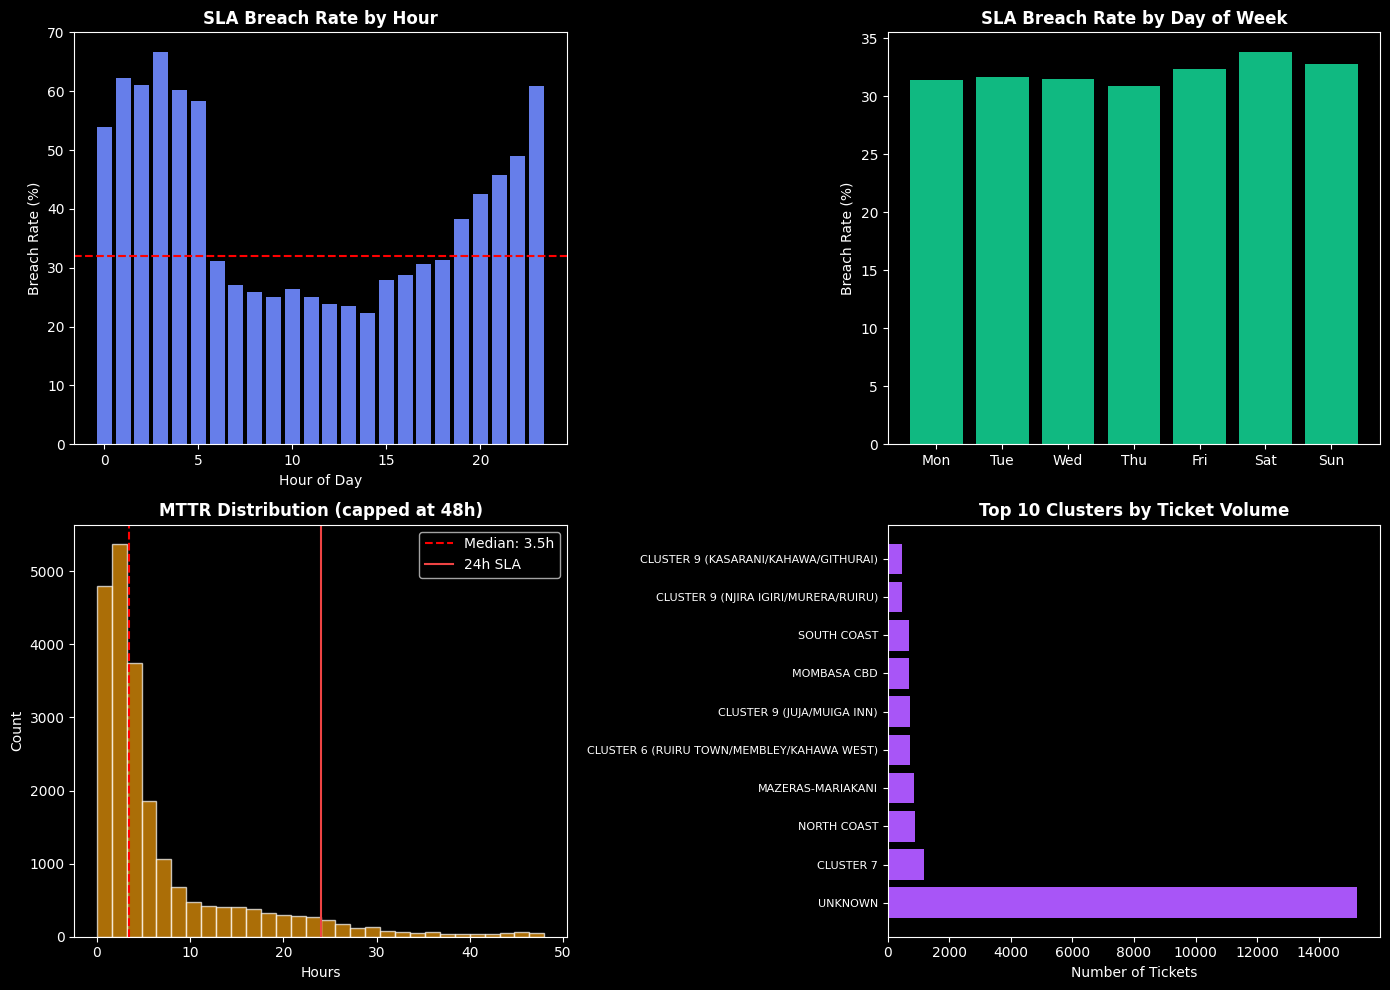

In [8]:
# SLA Breach Distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. SLA Breach by Hour
if 'SLA_BREACHED' in df_featured.columns and 'HOUR' in df_featured.columns:
    hourly_breach = df_featured.groupby('HOUR')['SLA_BREACHED'].mean() * 100
    axes[0, 0].bar(hourly_breach.index, hourly_breach.values, color='#667eea')
    axes[0, 0].set_title('SLA Breach Rate by Hour', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Hour of Day')
    axes[0, 0].set_ylabel('Breach Rate (%)')
    axes[0, 0].axhline(y=df_featured['SLA_BREACHED'].mean() * 100, color='red', linestyle='--', label='Average')

# 2. SLA Breach by Day of Week
if 'SLA_BREACHED' in df_featured.columns and 'DAY_OF_WEEK' in df_featured.columns:
    dow_breach = df_featured.groupby('DAY_OF_WEEK')['SLA_BREACHED'].mean() * 100
    days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    axes[0, 1].bar(range(7), [dow_breach.get(i, 0) for i in range(7)], color='#10b981')
    axes[0, 1].set_xticks(range(7))
    axes[0, 1].set_xticklabels(days)
    axes[0, 1].set_title('SLA Breach Rate by Day of Week', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('Breach Rate (%)')

# 3. MTTR Distribution
if 'MTTR_HOURS' in df_featured.columns:
    mttr_data = df_featured['MTTR_HOURS'].dropna()
    mttr_data = mttr_data[mttr_data <= 48]  # Cap at 48 hours for visualization
    axes[1, 0].hist(mttr_data, bins=30, color='#f59e0b', edgecolor='white', alpha=0.7)
    axes[1, 0].axvline(x=mttr_data.median(), color='red', linestyle='--', label=f'Median: {mttr_data.median():.1f}h')
    axes[1, 0].axvline(x=24, color='#ef4444', linestyle='-', label='24h SLA')
    axes[1, 0].set_title('MTTR Distribution (capped at 48h)', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Hours')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].legend()

# 4. Top 10 Clusters by Tickets
if 'CLUSTER' in df_featured.columns:
    cluster_counts = df_featured['CLUSTER'].value_counts().head(10)
    axes[1, 1].barh(range(len(cluster_counts)), cluster_counts.values, color='#a855f7')
    axes[1, 1].set_yticks(range(len(cluster_counts)))
    axes[1, 1].set_yticklabels(cluster_counts.index, fontsize=8)
    axes[1, 1].set_title('Top 10 Clusters by Ticket Volume', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Number of Tickets')

plt.tight_layout()
plt.savefig('models/eda_plots.png', dpi=150, bbox_inches='tight', facecolor='#1e293b')
plt.show()
print("✓ EDA plots saved to models/eda_plots.png")

## 5. Prepare Data for Model Training

Define features and targets for each prediction task.

In [9]:
# Define feature columns for each model
FEATURE_COLS = [
    'HOUR', 'DAY_OF_WEEK', 'DAY_OF_MONTH', 'MONTH', 'WEEK_OF_YEAR',
    'IS_WEEKEND', 'IS_NIGHT', 'IS_BUSINESS_HOURS',
    'CLUSTER_ENCODED', 'REGION_ENCODED', 'SERVICE_ENCODED', 'CAUSE_ENCODED',
    'DAILY_TICKETS', 'DAILY_AVG_MTTR', 'DAILY_BREACH_RATE',
    'CLUSTER_AVG_MTTR', 'CLUSTER_STD_MTTR', 'CLUSTER_BREACH_RATE', 'CLUSTER_TOTAL_TICKETS'
]

# Filter to available columns
available_features = [col for col in FEATURE_COLS if col in df_featured.columns]
print(f"Available features: {len(available_features)}/{len(FEATURE_COLS)}")
print(available_features)

# Prepare the dataset
df_model = df_featured[available_features + ['SLA_BREACHED', 'MTTR_MINUTES', 'MTTR_HOURS', 'CLUSTER_ENCODED']].copy()
df_model = df_model.dropna()

print(f"\nDataset for modeling: {df_model.shape[0]:,} rows, {df_model.shape[1]} columns")
print(f"SLA Breach Rate: {df_model['SLA_BREACHED'].mean()*100:.1f}%")
print(f"Avg MTTR: {df_model['MTTR_HOURS'].mean():.2f} hours")

Available features: 19/19
['HOUR', 'DAY_OF_WEEK', 'DAY_OF_MONTH', 'MONTH', 'WEEK_OF_YEAR', 'IS_WEEKEND', 'IS_NIGHT', 'IS_BUSINESS_HOURS', 'CLUSTER_ENCODED', 'REGION_ENCODED', 'SERVICE_ENCODED', 'CAUSE_ENCODED', 'DAILY_TICKETS', 'DAILY_AVG_MTTR', 'DAILY_BREACH_RATE', 'CLUSTER_AVG_MTTR', 'CLUSTER_STD_MTTR', 'CLUSTER_BREACH_RATE', 'CLUSTER_TOTAL_TICKETS']

Dataset for modeling: 23,002 rows, 23 columns
SLA Breach Rate: 32.0%
Avg MTTR: 16.12 hours


In [10]:
# Train-Test Split (use temporal split to prevent data leakage)
# Sort by date and use last 20% as test set

# Prepare features and targets
X = df_model[available_features]
y_sla = df_model['SLA_BREACHED']  # Classification target
y_mttr = df_model['MTTR_MINUTES']  # Regression target
y_cluster = df_model['CLUSTER_ENCODED']  # Multi-class target

# Split: 80% train, 20% test
split_idx = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_sla_train, y_sla_test = y_sla.iloc[:split_idx], y_sla.iloc[split_idx:]
y_mttr_train, y_mttr_test = y_mttr.iloc[:split_idx], y_mttr.iloc[split_idx:]

print(f"Training set: {len(X_train):,} samples")
print(f"Test set: {len(X_test):,} samples")
print(f"\nTraining SLA breach rate: {y_sla_train.mean()*100:.1f}%")
print(f"Test SLA breach rate: {y_sla_test.mean()*100:.1f}%")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Data prepared and scaled for training")

Training set: 18,401 samples
Test set: 4,601 samples

Training SLA breach rate: 30.6%
Test SLA breach rate: 37.6%

✓ Data prepared and scaled for training


## 6. Model 1: SLA Breach Prediction (Classification)

Train multiple classifiers to predict whether a ticket will breach SLA.

In [11]:
# Store results for comparison
sla_results = {}

# 1. Random Forest Classifier
print("=" * 60)
print("Training Random Forest Classifier for SLA Breach")
print("=" * 60)

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train_scaled, y_sla_train)
rf_pred = rf_clf.predict(X_test_scaled)
rf_prob = rf_clf.predict_proba(X_test_scaled)[:, 1]

sla_results['Random Forest'] = {
    'accuracy': accuracy_score(y_sla_test, rf_pred),
    'precision': precision_score(y_sla_test, rf_pred),
    'recall': recall_score(y_sla_test, rf_pred),
    'f1': f1_score(y_sla_test, rf_pred),
    'auc_roc': roc_auc_score(y_sla_test, rf_prob),
    'model': rf_clf
}

print(f"Accuracy: {sla_results['Random Forest']['accuracy']:.4f}")
print(f"Precision: {sla_results['Random Forest']['precision']:.4f}")
print(f"Recall: {sla_results['Random Forest']['recall']:.4f}")
print(f"F1 Score: {sla_results['Random Forest']['f1']:.4f}")
print(f"AUC-ROC: {sla_results['Random Forest']['auc_roc']:.4f}")

Training Random Forest Classifier for SLA Breach
Accuracy: 0.7881
Precision: 0.6665
Recall: 0.8728
F1 Score: 0.7558
AUC-ROC: 0.9052


In [12]:
# 2. Gradient Boosting Classifier
print("\n" + "=" * 60)
print("Training Gradient Boosting Classifier for SLA Breach")
print("=" * 60)

gb_clf = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    min_samples_split=10,
    random_state=42
)

gb_clf.fit(X_train_scaled, y_sla_train)
gb_pred = gb_clf.predict(X_test_scaled)
gb_prob = gb_clf.predict_proba(X_test_scaled)[:, 1]

sla_results['Gradient Boosting'] = {
    'accuracy': accuracy_score(y_sla_test, gb_pred),
    'precision': precision_score(y_sla_test, gb_pred),
    'recall': recall_score(y_sla_test, gb_pred),
    'f1': f1_score(y_sla_test, gb_pred),
    'auc_roc': roc_auc_score(y_sla_test, gb_prob),
    'model': gb_clf
}

print(f"Accuracy: {sla_results['Gradient Boosting']['accuracy']:.4f}")
print(f"Precision: {sla_results['Gradient Boosting']['precision']:.4f}")
print(f"Recall: {sla_results['Gradient Boosting']['recall']:.4f}")
print(f"F1 Score: {sla_results['Gradient Boosting']['f1']:.4f}")
print(f"AUC-ROC: {sla_results['Gradient Boosting']['auc_roc']:.4f}")


Training Gradient Boosting Classifier for SLA Breach
Accuracy: 0.8174
Precision: 0.7399
Recall: 0.7929
F1 Score: 0.7655
AUC-ROC: 0.9145


In [13]:
# 3. XGBoost Classifier (if available)
if XGBOOST_AVAILABLE:
    print("\n" + "=" * 60)
    print("Training XGBoost Classifier for SLA Breach")
    print("=" * 60)

    xgb_clf = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=10,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=(len(y_sla_train) - y_sla_train.sum()) / y_sla_train.sum(),  # Handle imbalance
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        n_jobs=-1
    )

    xgb_clf.fit(X_train_scaled, y_sla_train)
    xgb_pred = xgb_clf.predict(X_test_scaled)
    xgb_prob = xgb_clf.predict_proba(X_test_scaled)[:, 1]

    sla_results['XGBoost'] = {
        'accuracy': accuracy_score(y_sla_test, xgb_pred),
        'precision': precision_score(y_sla_test, xgb_pred),
        'recall': recall_score(y_sla_test, xgb_pred),
        'f1': f1_score(y_sla_test, xgb_pred),
        'auc_roc': roc_auc_score(y_sla_test, xgb_prob),
        'model': xgb_clf
    }

    print(f"Accuracy: {sla_results['XGBoost']['accuracy']:.4f}")
    print(f"Precision: {sla_results['XGBoost']['precision']:.4f}")
    print(f"Recall: {sla_results['XGBoost']['recall']:.4f}")
    print(f"F1 Score: {sla_results['XGBoost']['f1']:.4f}")
    print(f"AUC-ROC: {sla_results['XGBoost']['auc_roc']:.4f}")


Training XGBoost Classifier for SLA Breach
Accuracy: 0.8027
Precision: 0.6865
Recall: 0.8739
F1 Score: 0.7690
AUC-ROC: 0.9158


In [14]:
# 4. LightGBM Classifier (if available)
if LIGHTGBM_AVAILABLE:
    print("\n" + "=" * 60)
    print("Training LightGBM Classifier for SLA Breach")
    print("=" * 60)

    lgb_clf = lgb.LGBMClassifier(
        n_estimators=300,
        max_depth=10,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    lgb_clf.fit(X_train_scaled, y_sla_train)
    lgb_pred = lgb_clf.predict(X_test_scaled)
    lgb_prob = lgb_clf.predict_proba(X_test_scaled)[:, 1]

    sla_results['LightGBM'] = {
        'accuracy': accuracy_score(y_sla_test, lgb_pred),
        'precision': precision_score(y_sla_test, lgb_pred),
        'recall': recall_score(y_sla_test, lgb_pred),
        'f1': f1_score(y_sla_test, lgb_pred),
        'auc_roc': roc_auc_score(y_sla_test, lgb_prob),
        'model': lgb_clf
    }

    print(f"Accuracy: {sla_results['LightGBM']['accuracy']:.4f}")
    print(f"Precision: {sla_results['LightGBM']['precision']:.4f}")
    print(f"Recall: {sla_results['LightGBM']['recall']:.4f}")
    print(f"F1 Score: {sla_results['LightGBM']['f1']:.4f}")
    print(f"AUC-ROC: {sla_results['LightGBM']['auc_roc']:.4f}")


Training LightGBM Classifier for SLA Breach
Accuracy: 0.7872
Precision: 0.6526
Recall: 0.9277
F1 Score: 0.7662
AUC-ROC: 0.9215


In [15]:
# Compare SLA Breach Models
print("\n" + "=" * 60)
print("SLA BREACH MODEL COMPARISON")
print("=" * 60)

comparison_df = pd.DataFrame({
    name: {k: v for k, v in metrics.items() if k != 'model'}
    for name, metrics in sla_results.items()
}).T

comparison_df = comparison_df.sort_values('auc_roc', ascending=False)
print(comparison_df.to_string())

# Find best model
best_sla_model_name = comparison_df['auc_roc'].idxmax()
best_sla_model = sla_results[best_sla_model_name]['model']
print(f"\n✓ Best SLA Breach Model: {best_sla_model_name} (AUC-ROC: {comparison_df.loc[best_sla_model_name, 'auc_roc']:.4f})")


SLA BREACH MODEL COMPARISON
                   accuracy  precision    recall        f1   auc_roc
LightGBM           0.787220   0.652563  0.927704  0.766181  0.921546
XGBoost            0.802652   0.686506  0.873916  0.768957  0.915800
Gradient Boosting  0.817431   0.739881  0.792944  0.765494  0.914493
Random Forest      0.788090   0.666519  0.872759  0.755823  0.905202

✓ Best SLA Breach Model: LightGBM (AUC-ROC: 0.9215)


## 7. Model 2: MTTR Prediction (Regression)

Train regression models to predict Mean Time To Repair in minutes.

In [16]:
# Store MTTR regression results
mttr_results = {}

# 1. Random Forest Regressor
print("=" * 60)
print("Training Random Forest Regressor for MTTR Prediction")
print("=" * 60)

rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)

rf_reg.fit(X_train_scaled, y_mttr_train)
rf_mttr_pred = rf_reg.predict(X_test_scaled)

mttr_results['Random Forest'] = {
    'mae': mean_absolute_error(y_mttr_test, rf_mttr_pred),
    'rmse': np.sqrt(mean_squared_error(y_mttr_test, rf_mttr_pred)),
    'r2': r2_score(y_mttr_test, rf_mttr_pred),
    'model': rf_reg
}

print(f"MAE: {mttr_results['Random Forest']['mae']:.2f} minutes")
print(f"RMSE: {mttr_results['Random Forest']['rmse']:.2f} minutes")
print(f"R² Score: {mttr_results['Random Forest']['r2']:.4f}")

Training Random Forest Regressor for MTTR Prediction
MAE: 755.84 minutes
RMSE: 3417.50 minutes
R² Score: 0.1607


In [17]:
# 2. Gradient Boosting Regressor
print("\n" + "=" * 60)
print("Training Gradient Boosting Regressor for MTTR Prediction")
print("=" * 60)

gb_reg = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    min_samples_split=10,
    random_state=42
)

gb_reg.fit(X_train_scaled, y_mttr_train)
gb_mttr_pred = gb_reg.predict(X_test_scaled)

mttr_results['Gradient Boosting'] = {
    'mae': mean_absolute_error(y_mttr_test, gb_mttr_pred),
    'rmse': np.sqrt(mean_squared_error(y_mttr_test, gb_mttr_pred)),
    'r2': r2_score(y_mttr_test, gb_mttr_pred),
    'model': gb_reg
}

print(f"MAE: {mttr_results['Gradient Boosting']['mae']:.2f} minutes")
print(f"RMSE: {mttr_results['Gradient Boosting']['rmse']:.2f} minutes")
print(f"R² Score: {mttr_results['Gradient Boosting']['r2']:.4f}")


Training Gradient Boosting Regressor for MTTR Prediction
MAE: 830.66 minutes
RMSE: 4133.76 minutes
R² Score: -0.2280


In [18]:
# 3. XGBoost Regressor (if available)
if XGBOOST_AVAILABLE:
    print("\n" + "=" * 60)
    print("Training XGBoost Regressor for MTTR Prediction")
    print("=" * 60)

    xgb_reg = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=10,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    xgb_reg.fit(X_train_scaled, y_mttr_train)
    xgb_mttr_pred = xgb_reg.predict(X_test_scaled)

    mttr_results['XGBoost'] = {
        'mae': mean_absolute_error(y_mttr_test, xgb_mttr_pred),
        'rmse': np.sqrt(mean_squared_error(y_mttr_test, xgb_mttr_pred)),
        'r2': r2_score(y_mttr_test, xgb_mttr_pred),
        'model': xgb_reg
    }

    print(f"MAE: {mttr_results['XGBoost']['mae']:.2f} minutes")
    print(f"RMSE: {mttr_results['XGBoost']['rmse']:.2f} minutes")
    print(f"R² Score: {mttr_results['XGBoost']['r2']:.4f}")

# 4. LightGBM Regressor (if available)
if LIGHTGBM_AVAILABLE:
    print("\n" + "=" * 60)
    print("Training LightGBM Regressor for MTTR Prediction")
    print("=" * 60)

    lgb_reg = lgb.LGBMRegressor(
        n_estimators=300,
        max_depth=10,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    lgb_reg.fit(X_train_scaled, y_mttr_train)
    lgb_mttr_pred = lgb_reg.predict(X_test_scaled)

    mttr_results['LightGBM'] = {
        'mae': mean_absolute_error(y_mttr_test, lgb_mttr_pred),
        'rmse': np.sqrt(mean_squared_error(y_mttr_test, lgb_mttr_pred)),
        'r2': r2_score(y_mttr_test, lgb_mttr_pred),
        'model': lgb_reg
    }

    print(f"MAE: {mttr_results['LightGBM']['mae']:.2f} minutes")
    print(f"RMSE: {mttr_results['LightGBM']['rmse']:.2f} minutes")
    print(f"R² Score: {mttr_results['LightGBM']['r2']:.4f}")


Training XGBoost Regressor for MTTR Prediction
MAE: 985.28 minutes
RMSE: 3759.26 minutes
R² Score: -0.0156

Training LightGBM Regressor for MTTR Prediction
MAE: 860.65 minutes
RMSE: 3651.95 minutes
R² Score: 0.0416


In [19]:
# Compare MTTR Models
print("\n" + "=" * 60)
print("MTTR PREDICTION MODEL COMPARISON")
print("=" * 60)

mttr_comparison_df = pd.DataFrame({
    name: {k: v for k, v in metrics.items() if k != 'model'}
    for name, metrics in mttr_results.items()
}).T

mttr_comparison_df = mttr_comparison_df.sort_values('r2', ascending=False)
print(mttr_comparison_df.to_string())

# Find best model (lowest MAE or highest R²)
best_mttr_model_name = mttr_comparison_df['r2'].idxmax()
best_mttr_model = mttr_results[best_mttr_model_name]['model']
print(f"\n✓ Best MTTR Model: {best_mttr_model_name} (R²: {mttr_comparison_df.loc[best_mttr_model_name, 'r2']:.4f})")


MTTR PREDICTION MODEL COMPARISON
                          mae         rmse        r2
Random Forest      755.836627  3417.504090  0.160688
LightGBM           860.649171  3651.945584  0.041584
XGBoost            985.277035  3759.259297 -0.015571
Gradient Boosting  830.656104  4133.761361 -0.227994

✓ Best MTTR Model: Random Forest (R²: 0.1607)


## 8. Model 3: Daily Ticket Volume Prediction (Time Series)

Train a model to predict daily ticket counts for workload planning.

In [20]:
# Prepare time series data for ticket volume prediction
# Use the engineered dataframe (df_featured) which already contains DATE, INC, SLA_BREACHED and MTTR_HOURS
daily_tickets = df_featured.copy()

# Ensure DATE is a datetime
daily_tickets['DATE'] = pd.to_datetime(daily_tickets['DATE'])

# Aggregate daily ticket counts
daily_tickets = daily_tickets.groupby('DATE').agg({
    'INC': 'count',
    'SLA_BREACHED': 'sum',
    'MTTR_HOURS': 'mean'
}).rename(columns={'INC': 'TICKET_COUNT', 'SLA_BREACHED': 'SLA_BREACHES', 'MTTR_HOURS': 'AVG_MTTR'})

daily_tickets = daily_tickets.reset_index().sort_values('DATE')

# Create time-based features
daily_tickets['DAY_OF_WEEK'] = daily_tickets['DATE'].dt.dayofweek
daily_tickets['DAY_OF_MONTH'] = daily_tickets['DATE'].dt.day
daily_tickets['MONTH'] = daily_tickets['DATE'].dt.month
daily_tickets['WEEK_OF_YEAR'] = daily_tickets['DATE'].dt.isocalendar().week.astype(int)
daily_tickets['IS_WEEKEND'] = (daily_tickets['DAY_OF_WEEK'] >= 5).astype(int)
daily_tickets['IS_MONTH_START'] = (daily_tickets['DAY_OF_MONTH'] <= 5).astype(int)
daily_tickets['IS_MONTH_END'] = (daily_tickets['DAY_OF_MONTH'] >= 25).astype(int)

# Lag features (previous days)
for lag in [1, 2, 3, 7, 14]:
    daily_tickets[f'LAG_{lag}'] = daily_tickets['TICKET_COUNT'].shift(lag)

# Rolling statistics
for window in [7, 14, 30]:
    daily_tickets[f'ROLLING_MEAN_{window}'] = daily_tickets['TICKET_COUNT'].rolling(window=window).mean()
    daily_tickets[f'ROLLING_STD_{window}'] = daily_tickets['TICKET_COUNT'].rolling(window=window).std()

# Drop NaN rows created by lag/rolling features
daily_tickets_clean = daily_tickets.dropna()

print(f"Daily tickets dataset: {len(daily_tickets_clean)} days")
daily_tickets_clean.head(10)

Daily tickets dataset: 1869 days


,DATE,TICKET_COUNT,SLA_BREACHES,AVG_MTTR,DAY_OF_WEEK,DAY_OF_MONTH,MONTH,WEEK_OF_YEAR,IS_WEEKEND,IS_MONTH_START,...,LAG_2,LAG_3,LAG_7,LAG_14,ROLLING_MEAN_7,ROLLING_STD_7,ROLLING_MEAN_14,ROLLING_STD_14,ROLLING_MEAN_30,ROLLING_STD_30
29,2020-09-29,7,3,17.105913,1,29,9,40,0,0,...,1.0,4.0,5.0,7.0,4.000000,3.366502,4.500000,3.299184,3.733333,2.839783
30,2020-09-30,3,1,20.552315,2,30,9,40,0,0,...,2.0,1.0,10.0,4.0,3.000000,2.081666,4.428571,3.321591,3.800000,2.796550
31,2020-10-01,3,0,4.450278,3,1,10,40,0,1,...,7.0,2.0,1.0,12.0,3.285714,1.889822,3.785714,2.516975,3.866667,2.750966
32,2020-10-02,4,1,50.101458,4,2,10,40,0,1,...,3.0,7.0,3.0,2.0,3.428571,1.902379,3.928571,2.464027,3.966667,2.697168
33,2020-10-03,1,0,3.296667,5,3,10,40,1,1,...,3.0,3.0,4.0,6.0,3.000000,2.081666,3.571429,2.502746,3.966667,2.697168
34,2020-10-05,9,4,5.535216,0,5,10,41,0,1,...,4.0,3.0,1.0,4.0,4.142857,2.853569,3.928571,2.894671,4.166667,2.841604
35,2020-10-06,2,1,3.515139,1,6,10,41,0,0,...,1.0,4.0,2.0,2.0,4.142857,2.853569,3.928571,2.894671,4.133333,2.861557
36,2020-10-07,2,1,100.479444,2,7,10,41,0,0,...,9.0,1.0,7.0,5.0,3.428571,2.636737,3.714286,2.920184,4.166667,2.829443
37,2020-10-08,3,0,2.795833,3,8,10,41,0,0,...,2.0,9.0,3.0,10.0,3.428571,2.636737,3.214286,2.293086,4.100000,2.832691
38,2020-10-10,2,1,4.106250,5,10,10,41,1,0,...,2.0,2.0,3.0,1.0,3.285714,2.690371,3.285714,2.233609,4.100000,2.832691


In [21]:
# Train Ticket Volume Models
volume_features = ['DAY_OF_WEEK', 'DAY_OF_MONTH', 'MONTH', 'WEEK_OF_YEAR',
                   'IS_WEEKEND', 'IS_MONTH_START', 'IS_MONTH_END',
                   'LAG_1', 'LAG_2', 'LAG_3', 'LAG_7', 'LAG_14',
                   'ROLLING_MEAN_7', 'ROLLING_STD_7',
                   'ROLLING_MEAN_14', 'ROLLING_STD_14',
                   'ROLLING_MEAN_30', 'ROLLING_STD_30']

X_volume = daily_tickets_clean[volume_features]
y_volume = daily_tickets_clean['TICKET_COUNT']

# Temporal split (last 30 days for testing)
split_idx = len(X_volume) - 30
X_vol_train, X_vol_test = X_volume.iloc[:split_idx], X_volume.iloc[split_idx:]
y_vol_train, y_vol_test = y_volume.iloc[:split_idx], y_volume.iloc[split_idx:]

print(f"Volume Train: {len(X_vol_train)}, Test: {len(X_vol_test)}")

# Scale features
scaler_volume = StandardScaler()
X_vol_train_scaled = scaler_volume.fit_transform(X_vol_train)
X_vol_test_scaled = scaler_volume.transform(X_vol_test)

volume_results = {}

# Random Forest
rf_vol = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_vol.fit(X_vol_train_scaled, y_vol_train)
rf_pred = rf_vol.predict(X_vol_test_scaled)
volume_results['Random Forest'] = {
    'MAE': mean_absolute_error(y_vol_test, rf_pred),
    'RMSE': np.sqrt(mean_squared_error(y_vol_test, rf_pred)),
    'R2': r2_score(y_vol_test, rf_pred),
    'model': rf_vol
}

# XGBoost
xgb_vol = xgb.XGBRegressor(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
xgb_vol.fit(X_vol_train_scaled, y_vol_train)
xgb_pred = xgb_vol.predict(X_vol_test_scaled)
volume_results['XGBoost'] = {
    'MAE': mean_absolute_error(y_vol_test, xgb_pred),
    'RMSE': np.sqrt(mean_squared_error(y_vol_test, xgb_pred)),
    'R2': r2_score(y_vol_test, xgb_pred),
    'model': xgb_vol
}

# LightGBM
lgb_vol = lgb.LGBMRegressor(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1, verbose=-1)
lgb_vol.fit(X_vol_train_scaled, y_vol_train)
lgb_pred = lgb_vol.predict(X_vol_test_scaled)
volume_results['LightGBM'] = {
    'MAE': mean_absolute_error(y_vol_test, lgb_pred),
    'RMSE': np.sqrt(mean_squared_error(y_vol_test, lgb_pred)),
    'R2': r2_score(y_vol_test, lgb_pred),
    'model': lgb_vol
}

# Display results
print("\n📊 TICKET VOLUME PREDICTION RESULTS")
print("=" * 60)
for name, metrics in volume_results.items():
    print(f"\n{name}:")
    print(f"  MAE: {metrics['MAE']:.2f} tickets")
    print(f"  RMSE: {metrics['RMSE']:.2f} tickets")
    print(f"  R²: {metrics['R2']:.4f}")

Volume Train: 1839, Test: 30

📊 TICKET VOLUME PREDICTION RESULTS

Random Forest:
  MAE: 2.99 tickets
  RMSE: 3.95 tickets
  R²: 0.3411

XGBoost:
  MAE: 2.61 tickets
  RMSE: 3.50 tickets
  R²: 0.4818

LightGBM:
  MAE: 3.03 tickets
  RMSE: 4.14 tickets
  R²: 0.2763


## 9. Hyperparameter Tuning with Optuna

Optimize the best performing models using Optuna for automated hyperparameter search.

In [27]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 13.0 MB/s eta 0:00:00


In [28]:
# Hyperparameter Tuning for SLA Breach Model (XGBoost/LightGBM - choose best)
import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_sla(trial):
    """Objective function for SLA Breach classification"""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 10),
        'random_state': 42,
        'n_jobs': -1,
        'use_label_encoder': False,
        'eval_metric': 'logloss'
    }

    model = xgb.XGBClassifier(**params)

    # Cross-validation
    from sklearn.model_selection import cross_val_score
    # Use the correctly named target variable y_sla_train (defined earlier in the notebook)
    scores = cross_val_score(model, X_train_scaled, y_sla_train, cv=3, scoring='f1')
    return scores.mean()

# Run optimization
print("🔍 Optimizing SLA Breach Model (XGBoost)...")
study_sla = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_sla.optimize(objective_sla, n_trials=50, show_progress_bar=True)

print(f"\n✅ Best F1 Score: {study_sla.best_value:.4f}")
print(f"Best Parameters: {study_sla.best_params}")

🔍 Optimizing SLA Breach Model (XGBoost)...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Best F1 Score: 0.6958
Best Parameters: {'n_estimators': 252, 'max_depth': 4, 'learning_rate': 0.015233344011959912, 'min_child_weight': 9, 'subsample': 0.6576941952027856, 'colsample_bytree': 0.7097800000353492, 'reg_alpha': 0.0001346157368130535, 'reg_lambda': 1.4540062931532652e-05, 'scale_pos_weight': 2.649928271193141}


In [29]:
# Train optimized SLA Breach model with best parameters
best_sla_params = study_sla.best_params.copy()
best_sla_params['random_state'] = 42
best_sla_params['n_jobs'] = -1
best_sla_params['use_label_encoder'] = False
best_sla_params['eval_metric'] = 'logloss'

optimized_sla_model = xgb.XGBClassifier(**best_sla_params)
# use the correctly named target variable from earlier cells
optimized_sla_model.fit(X_train_scaled, y_sla_train)

# Evaluate
y_pred_optimized = optimized_sla_model.predict(X_test_scaled)
y_prob_optimized = optimized_sla_model.predict_proba(X_test_scaled)[:, 1]

print("📊 OPTIMIZED SLA BREACH MODEL PERFORMANCE")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_sla_test, y_pred_optimized):.4f}")
print(f"Precision: {precision_score(y_sla_test, y_pred_optimized):.4f}")
print(f"Recall: {recall_score(y_sla_test, y_pred_optimized):.4f}")
print(f"F1 Score: {f1_score(y_sla_test, y_pred_optimized):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_sla_test, y_prob_optimized):.4f}")

print("\nClassification Report:")
print(classification_report(y_sla_test, y_pred_optimized, target_names=['No Breach', 'SLA Breach']))

📊 OPTIMIZED SLA BREACH MODEL PERFORMANCE
Accuracy: 0.7477
Precision: 0.6021
Recall: 0.9688
F1 Score: 0.7426
ROC-AUC: 0.9167

Classification Report:
              precision    recall  f1-score   support

   No Breach       0.97      0.61      0.75      2872
  SLA Breach       0.60      0.97      0.74      1729

    accuracy                           0.75      4601
   macro avg       0.79      0.79      0.75      4601
weighted avg       0.83      0.75      0.75      4601



In [30]:
# Hyperparameter Tuning for MTTR Model (XGBoost Regressor)
def objective_mttr(trial):
    """Objective function for MTTR regression"""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1
    }

    model = xgb.XGBRegressor(**params)

    from sklearn.model_selection import cross_val_score
    # Use the already prepared training arrays X_train_scaled and y_mttr_train
    # Use negative MAE (higher is better in sklearn convention)
    scores = cross_val_score(model, X_train_scaled, y_mttr_train, cv=3, scoring='neg_mean_absolute_error')
    return scores.mean()

# Run optimization
print("🔍 Optimizing MTTR Model (XGBoost)...")
study_mttr = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_mttr.optimize(objective_mttr, n_trials=50, show_progress_bar=True)

print(f"\n✅ Best MAE: {-study_mttr.best_value:.4f} hours")
print(f"Best Parameters: {study_mttr.best_params}")

🔍 Optimizing MTTR Model (XGBoost)...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Best MAE: 1023.5275 hours
Best Parameters: {'n_estimators': 236, 'max_depth': 5, 'learning_rate': 0.013362332569479676, 'min_child_weight': 6, 'subsample': 0.7330932440011494, 'colsample_bytree': 0.9675811342428398, 'reg_alpha': 3.6079258865222734e-07, 'reg_lambda': 0.001954893776861597}


In [31]:
# Train optimized MTTR model with best parameters
best_mttr_params = study_mttr.best_params.copy()
best_mttr_params['random_state'] = 42
best_mttr_params['n_jobs'] = -1

# Use the already prepared training arrays from earlier cells
# X_train_scaled / X_test_scaled and y_mttr_train / y_mttr_test are defined in the notebook
optimized_mttr_model = xgb.XGBRegressor(**best_mttr_params)
optimized_mttr_model.fit(X_train_scaled, y_mttr_train)

# Evaluate on the existing test split
y_pred_mttr_opt = optimized_mttr_model.predict(X_test_scaled)

mae = mean_absolute_error(y_mttr_test, y_pred_mttr_opt)
rmse = np.sqrt(mean_squared_error(y_mttr_test, y_pred_mttr_opt))
r2 = r2_score(y_mttr_test, y_pred_mttr_opt)

print("📊 OPTIMIZED MTTR MODEL PERFORMANCE")
print("=" * 50)
# MTTR target is in minutes; print both minutes and hours for clarity
print(f"MAE: {mae:.4f} minutes ({mae/60:.4f} hours)")
print(f"RMSE: {rmse:.4f} minutes ({rmse/60:.4f} hours)")
print(f"R² Score: {r2:.4f}")

📊 OPTIMIZED MTTR MODEL PERFORMANCE
MAE: 735.2489 minutes (12.2541 hours)
RMSE: 3352.6097 minutes (55.8768 hours)
R² Score: 0.1923


## 10. Feature Importance Analysis

Understand which features contribute most to predictions.

FileNotFoundError: [Errno 2] No such file or directory: './models/feature_importance.png'

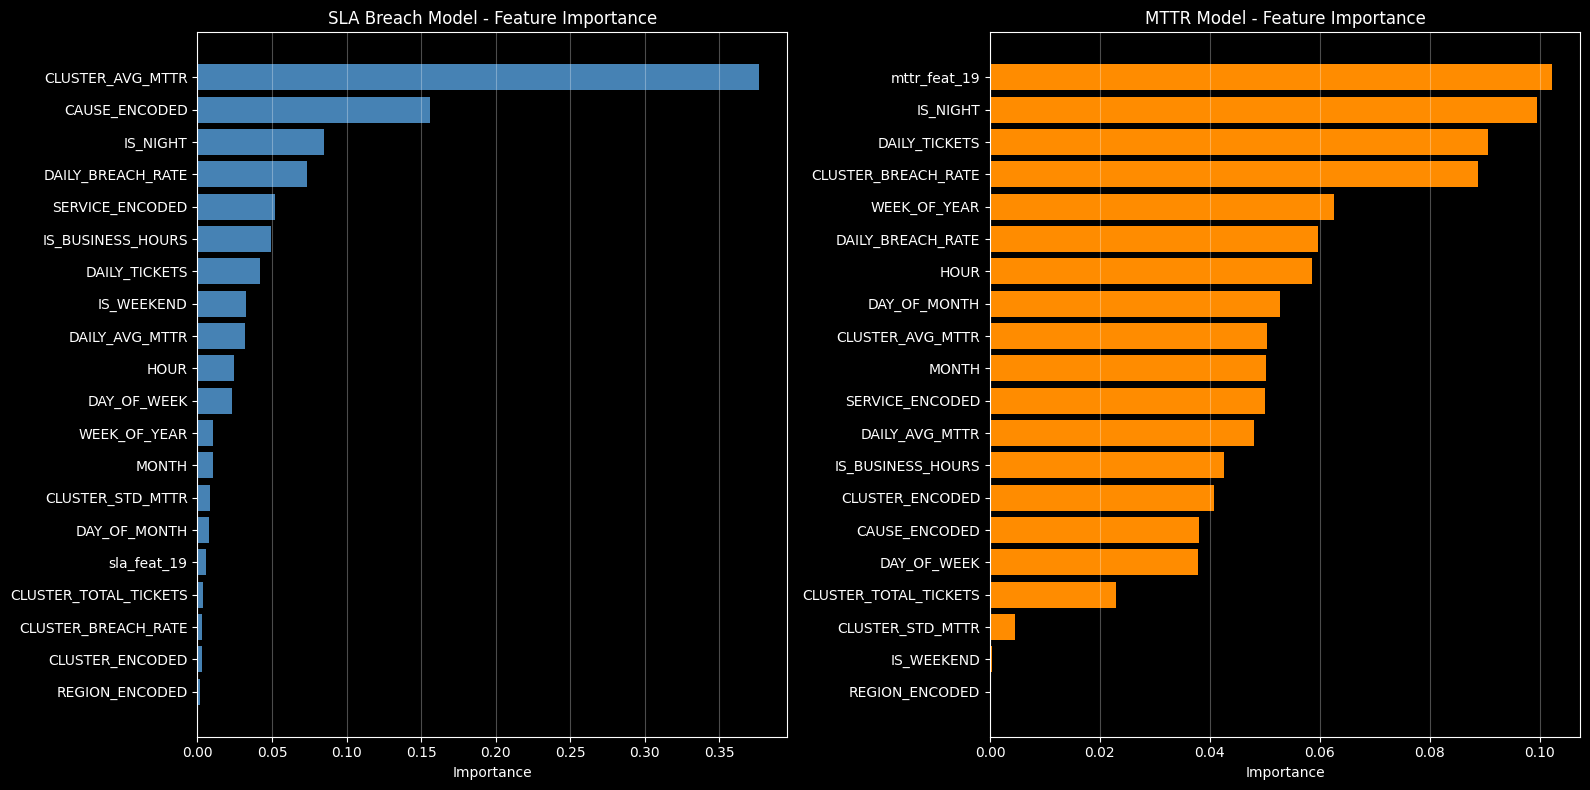

In [32]:
# Feature Importance for SLA Breach & MTTR Models
# NOTE: ensure 'available_features' or a usable feature list exists and models are trained

# Resolve feature list: prefer available_features, then features, then FEATURE_COLS
if 'available_features' in globals():
    base_features = list(available_features)
elif 'features' in globals():
    base_features = list(features)
elif 'FEATURE_COLS' in globals():
    base_features = [f for f in FEATURE_COLS if f in df_featured.columns]
else:
    raise NameError("No feature list found. Define 'available_features', 'features' or 'FEATURE_COLS' before computing importances.")

# Helper to align feature names to model importances length
def aligned_feature_names(feature_list, importances, prefix='feature'):
    n_imp = len(importances)
    if len(feature_list) == n_imp:
        return feature_list
    elif len(feature_list) > n_imp:
        # truncate if too many names
        return feature_list[:n_imp]
    else:
        # extend with generic names if model has more importances than names
        extra = [f"{prefix}_{i}" for i in range(len(feature_list), n_imp)]
        return feature_list + extra

# Get SLA importances (robustly)
sla_imp = getattr(optimized_sla_model, 'feature_importances_', None)
if sla_imp is None:
    raise AttributeError("optimized_sla_model has no attribute 'feature_importances_'. Compute importances differently for this model type.")

sla_features = aligned_feature_names(base_features, sla_imp, prefix='sla_feat')

sla_importance = pd.DataFrame({
    'feature': sla_features,
    'importance': sla_imp
}).sort_values('importance', ascending=True)

# Get MTTR importances (robustly)
mttr_imp = getattr(optimized_mttr_model, 'feature_importances_', None)
if mttr_imp is None:
    raise AttributeError("optimized_mttr_model has no attribute 'feature_importances_'. Compute importances differently for this model type.")

mttr_features = aligned_feature_names(base_features, mttr_imp, prefix='mttr_feat')

mttr_importance = pd.DataFrame({
    'feature': mttr_features,
    'importance': mttr_imp
}).sort_values('importance', ascending=True)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(sla_importance['feature'], sla_importance['importance'], color='steelblue')
axes[0].set_xlabel('Importance')
axes[0].set_title('SLA Breach Model - Feature Importance')
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(mttr_importance['feature'], mttr_importance['importance'], color='darkorange')
axes[1].set_xlabel('Importance')
axes[1].set_title('MTTR Model - Feature Importance')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('./models/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top features
print("\n📈 Top 10 Features for SLA Breach Prediction:")
for _, row in sla_importance.tail(10).iterrows():
    print(f"  {row['feature']}: {row['importance']:.6f}")

print("\n📈 Top 10 Features for MTTR Prediction:")
for _, row in mttr_importance.tail(10).iterrows():
    print(f"  {row['feature']}: {row['importance']:.6f}")

## 🚀 PHASE 2: Heavy-Duty Model Training

Now we train much more powerful models:
1. **Heavy XGBoost/LightGBM** with more estimators and deeper trees
2. **CatBoost** (if available) - excellent for categorical data
3. **Stacking Ensemble** - combining multiple models
4. **Voting Ensemble** - democratic model combination
5. **Neural Networks (MLP)** - deep learning approach
6. **Extended Hyperparameter Search** with more trials

In [33]:
# Import additional libraries for advanced models
from sklearn.ensemble import StackingClassifier, StackingRegressor
from sklearn.ensemble import VotingClassifier, VotingRegressor
from sklearn.ensemble import AdaBoostClassifier, AdaBoostRegressor
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor
from sklearn.ensemble import BaggingClassifier, BaggingRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.linear_model import LogisticRegression, ElasticNet
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.calibration import CalibratedClassifierCV

# Check for CatBoost
try:
    from catboost import CatBoostClassifier, CatBoostRegressor
    CATBOOST_AVAILABLE = True
    print("✅ CatBoost available")
except ImportError:
    CATBOOST_AVAILABLE = False
    print("⚠️ CatBoost not available")

print("✅ All advanced model libraries imported!")
print(f"\nTraining data shape: {X_train_scaled.shape}")
print(f"Test data shape: {X_test_scaled.shape}")
print(f"SLA Breach rate in training: {y_sla_train.mean()*100:.1f}%")

⚠️ CatBoost not available
✅ All advanced model libraries imported!

Training data shape: (18401, 20)
Test data shape: (4601, 20)
SLA Breach rate in training: 30.6%


In [34]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.6 MB/s eta 0:00:00


### 2.1 Heavy XGBoost Classifier for SLA Breach

Train XGBoost with much higher n_estimators and deeper trees.

In [35]:
# Heavy XGBoost Classifier - Much more powerful configuration
print("=" * 70)
print("🔥 Training HEAVY XGBoost Classifier for SLA Breach")
print("=" * 70)

# Calculate scale_pos_weight for class imbalance
scale_pos_weight = (len(y_sla_train) - y_sla_train.sum()) / y_sla_train.sum()
print(f"Class imbalance ratio: {scale_pos_weight:.2f}")

heavy_xgb_clf = xgb.XGBClassifier(
    n_estimators=1000,           # Much more trees
    max_depth=12,                # Deeper trees
    learning_rate=0.02,          # Lower learning rate for better convergence
    min_child_weight=3,
    gamma=0.1,
    subsample=0.85,
    colsample_bytree=0.85,
    colsample_bylevel=0.85,
    reg_alpha=0.5,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    max_delta_step=1,            # Helps with imbalanced classes
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='auc',
    early_stopping_rounds=50
)

# Train with early stopping
eval_set = [(X_train_scaled, y_sla_train), (X_test_scaled, y_sla_test)]
heavy_xgb_clf.fit(X_train_scaled, y_sla_train,
                  eval_set=eval_set,
                  verbose=100)

# Predictions
heavy_xgb_pred = heavy_xgb_clf.predict(X_test_scaled)
heavy_xgb_prob = heavy_xgb_clf.predict_proba(X_test_scaled)[:, 1]

print("\n📊 Heavy XGBoost SLA Breach Results:")
print(f"  Accuracy:  {accuracy_score(y_sla_test, heavy_xgb_pred):.4f}")
print(f"  Precision: {precision_score(y_sla_test, heavy_xgb_pred):.4f}")
print(f"  Recall:    {recall_score(y_sla_test, heavy_xgb_pred):.4f}")
print(f"  F1 Score:  {f1_score(y_sla_test, heavy_xgb_pred):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_sla_test, heavy_xgb_prob):.4f}")

🔥 Training HEAVY XGBoost Classifier for SLA Breach
Class imbalance ratio: 2.27
[0]	validation_0-auc:0.85800	validation_1-auc:0.77316
[100]	validation_0-auc:0.95405	validation_1-auc:0.91835
[200]	validation_0-auc:0.96418	validation_1-auc:0.92001
[228]	validation_0-auc:0.96737	validation_1-auc:0.92012

📊 Heavy XGBoost SLA Breach Results:
  Accuracy:  0.7864
  Precision: 0.6520
  Recall:    0.9254
  F1 Score:  0.7650
  ROC-AUC:   0.9203


In [36]:
# Heavy LightGBM Classifier
print("\n" + "=" * 70)
print("🔥 Training HEAVY LightGBM Classifier for SLA Breach")
print("=" * 70)

heavy_lgb_clf = lgb.LGBMClassifier(
    n_estimators=1000,
    max_depth=15,
    learning_rate=0.02,
    num_leaves=127,              # More leaves = more complex patterns
    min_child_samples=20,
    subsample=0.85,
    subsample_freq=1,
    colsample_bytree=0.85,
    reg_alpha=0.5,
    reg_lambda=1.0,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1,
    importance_type='gain'
)

# Train with early stopping
heavy_lgb_clf.fit(
    X_train_scaled, y_sla_train,
    eval_set=[(X_test_scaled, y_sla_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

heavy_lgb_pred = heavy_lgb_clf.predict(X_test_scaled)
heavy_lgb_prob = heavy_lgb_clf.predict_proba(X_test_scaled)[:, 1]

print("\n📊 Heavy LightGBM SLA Breach Results:")
print(f"  Accuracy:  {accuracy_score(y_sla_test, heavy_lgb_pred):.4f}")
print(f"  Precision: {precision_score(y_sla_test, heavy_lgb_pred):.4f}")
print(f"  Recall:    {recall_score(y_sla_test, heavy_lgb_pred):.4f}")
print(f"  F1 Score:  {f1_score(y_sla_test, heavy_lgb_pred):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_sla_test, heavy_lgb_prob):.4f}")


🔥 Training HEAVY LightGBM Classifier for SLA Breach

📊 Heavy LightGBM SLA Breach Results:
  Accuracy:  0.8000
  Precision: 0.6769
  Recall:    0.8953
  F1 Score:  0.7709
  ROC-AUC:   0.9202


In [37]:
# CatBoost Classifier (if available)
if CATBOOST_AVAILABLE:
    print("\n" + "=" * 70)
    print("🔥 Training HEAVY CatBoost Classifier for SLA Breach")
    print("=" * 70)

    heavy_cat_clf = CatBoostClassifier(
        iterations=1000,
        depth=10,
        learning_rate=0.03,
        l2_leaf_reg=5,
        border_count=254,
        bagging_temperature=0.5,
        random_strength=0.5,
        auto_class_weights='Balanced',
        random_state=42,
        verbose=100,
        early_stopping_rounds=50
    )

    heavy_cat_clf.fit(X_train_scaled, y_sla_train,
                      eval_set=(X_test_scaled, y_sla_test))

    heavy_cat_pred = heavy_cat_clf.predict(X_test_scaled)
    heavy_cat_prob = heavy_cat_clf.predict_proba(X_test_scaled)[:, 1]

    print("\n📊 Heavy CatBoost SLA Breach Results:")
    print(f"  Accuracy:  {accuracy_score(y_sla_test, heavy_cat_pred):.4f}")
    print(f"  Precision: {precision_score(y_sla_test, heavy_cat_pred):.4f}")
    print(f"  Recall:    {recall_score(y_sla_test, heavy_cat_pred):.4f}")
    print(f"  F1 Score:  {f1_score(y_sla_test, heavy_cat_pred):.4f}")
    print(f"  ROC-AUC:   {roc_auc_score(y_sla_test, heavy_cat_prob):.4f}")
else:
    print("⚠️ CatBoost not available, skipping...")

⚠️ CatBoost not available, skipping...


### 2.2 Neural Network (MLP) for SLA Breach

Deep learning approach with multiple hidden layers.

In [38]:
# Neural Network Classifier (MLP) - Deep architecture
print("\n" + "=" * 70)
print("🧠 Training Neural Network (MLP) Classifier for SLA Breach")
print("=" * 70)

# Get number of features for architecture design
n_features = X_train_scaled.shape[1]
print(f"Input features: {n_features}")

# Deep MLP with multiple architectures to try
mlp_architectures = [
    (256, 128, 64, 32),           # Wide and deep
    (512, 256, 128, 64),          # Very wide and deep
    (128, 128, 128, 64, 32),      # Uniform deep
]

best_mlp_clf = None
best_mlp_score = 0

for arch in mlp_architectures:
    print(f"\n  Testing architecture: {arch}")

    mlp_clf = MLPClassifier(
        hidden_layer_sizes=arch,
        activation='relu',
        solver='adam',
        alpha=0.0001,              # L2 regularization
        batch_size=64,
        learning_rate='adaptive',
        learning_rate_init=0.001,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=42,
        verbose=False
    )

    mlp_clf.fit(X_train_scaled, y_sla_train)
    mlp_prob = mlp_clf.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_sla_test, mlp_prob)

    print(f"    ROC-AUC: {auc:.4f}")

    if auc > best_mlp_score:
        best_mlp_score = auc
        best_mlp_clf = mlp_clf
        best_arch = arch

print(f"\n✅ Best MLP architecture: {best_arch}")

# Final evaluation
mlp_pred = best_mlp_clf.predict(X_test_scaled)
mlp_prob = best_mlp_clf.predict_proba(X_test_scaled)[:, 1]

print("\n📊 Best Neural Network SLA Breach Results:")
print(f"  Accuracy:  {accuracy_score(y_sla_test, mlp_pred):.4f}")
print(f"  Precision: {precision_score(y_sla_test, mlp_pred):.4f}")
print(f"  Recall:    {recall_score(y_sla_test, mlp_pred):.4f}")
print(f"  F1 Score:  {f1_score(y_sla_test, mlp_pred):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_sla_test, mlp_prob):.4f}")


🧠 Training Neural Network (MLP) Classifier for SLA Breach
Input features: 20

  Testing architecture: (256, 128, 64, 32)
    ROC-AUC: 0.9046

  Testing architecture: (512, 256, 128, 64)
    ROC-AUC: 0.9031

  Testing architecture: (128, 128, 128, 64, 32)
    ROC-AUC: 0.8957

✅ Best MLP architecture: (256, 128, 64, 32)

📊 Best Neural Network SLA Breach Results:
  Accuracy:  0.8185
  Precision: 0.7590
  Recall:    0.7577
  F1 Score:  0.7583
  ROC-AUC:   0.9046


### 2.3 Ensemble Models for SLA Breach

Combine multiple models for better predictions.

In [39]:
# Voting Ensemble - Combine multiple classifiers
print("\n" + "=" * 70)
print("🗳️ Training Voting Ensemble Classifier for SLA Breach")
print("=" * 70)

# Create base estimators (use lighter versions for voting ensemble)
estimators_voting = [
    ('xgb', xgb.XGBClassifier(
        n_estimators=300, max_depth=8, learning_rate=0.05,
        scale_pos_weight=scale_pos_weight, random_state=42,
        n_jobs=-1, use_label_encoder=False, eval_metric='logloss'
    )),
    ('lgb', lgb.LGBMClassifier(
        n_estimators=300, max_depth=10, learning_rate=0.05,
        num_leaves=63, class_weight='balanced', random_state=42,
        n_jobs=-1, verbose=-1
    )),
    ('rf', RandomForestClassifier(
        n_estimators=300, max_depth=15, min_samples_split=5,
        class_weight='balanced', random_state=42, n_jobs=-1
    )),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(128, 64, 32), activation='relu',
        solver='adam', max_iter=300, early_stopping=True,
        random_state=42
    ))
]

# Soft voting (uses predicted probabilities)
voting_clf = VotingClassifier(
    estimators=estimators_voting,
    voting='soft',
    n_jobs=-1
)

print("Training voting ensemble (this may take a few minutes)...")
voting_clf.fit(X_train_scaled, y_sla_train)

voting_pred = voting_clf.predict(X_test_scaled)
voting_prob = voting_clf.predict_proba(X_test_scaled)[:, 1]

print("\n📊 Voting Ensemble SLA Breach Results:")
print(f"  Accuracy:  {accuracy_score(y_sla_test, voting_pred):.4f}")
print(f"  Precision: {precision_score(y_sla_test, voting_pred):.4f}")
print(f"  Recall:    {recall_score(y_sla_test, voting_pred):.4f}")
print(f"  F1 Score:  {f1_score(y_sla_test, voting_pred):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_sla_test, voting_prob):.4f}")


🗳️ Training Voting Ensemble Classifier for SLA Breach
Training voting ensemble (this may take a few minutes)...

📊 Voting Ensemble SLA Breach Results:
  Accuracy:  0.8053
  Precision: 0.6920
  Recall:    0.8681
  F1 Score:  0.7701
  ROC-AUC:   0.9175


In [40]:
# Stacking Ensemble - More sophisticated meta-learning
print("\n" + "=" * 70)
print("📚 Training Stacking Ensemble Classifier for SLA Breach")
print("=" * 70)

# Base estimators for stacking
estimators_stacking = [
    ('xgb', xgb.XGBClassifier(
        n_estimators=200, max_depth=8, learning_rate=0.05,
        scale_pos_weight=scale_pos_weight, random_state=42,
        n_jobs=-1, use_label_encoder=False, eval_metric='logloss'
    )),
    ('lgb', lgb.LGBMClassifier(
        n_estimators=200, max_depth=8, learning_rate=0.05,
        num_leaves=63, class_weight='balanced', random_state=42,
        n_jobs=-1, verbose=-1
    )),
    ('rf', RandomForestClassifier(
        n_estimators=200, max_depth=12, class_weight='balanced',
        random_state=42, n_jobs=-1
    )),
    ('et', ExtraTreesClassifier(
        n_estimators=200, max_depth=12, class_weight='balanced',
        random_state=42, n_jobs=-1
    ))
]

# Meta-learner (final estimator)
meta_learner = LogisticRegression(
    C=1.0, max_iter=1000, class_weight='balanced', random_state=42
)

stacking_clf = StackingClassifier(
    estimators=estimators_stacking,
    final_estimator=meta_learner,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1,
    passthrough=True  # Include original features too
)

print("Training stacking ensemble (this will take several minutes)...")
stacking_clf.fit(X_train_scaled, y_sla_train)

stacking_pred = stacking_clf.predict(X_test_scaled)
stacking_prob = stacking_clf.predict_proba(X_test_scaled)[:, 1]

print("\n📊 Stacking Ensemble SLA Breach Results:")
print(f"  Accuracy:  {accuracy_score(y_sla_test, stacking_pred):.4f}")
print(f"  Precision: {precision_score(y_sla_test, stacking_pred):.4f}")
print(f"  Recall:    {recall_score(y_sla_test, stacking_pred):.4f}")
print(f"  F1 Score:  {f1_score(y_sla_test, stacking_pred):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_sla_test, stacking_prob):.4f}")


📚 Training Stacking Ensemble Classifier for SLA Breach
Training stacking ensemble (this will take several minutes)...

📊 Stacking Ensemble SLA Breach Results:
  Accuracy:  0.7920
  Precision: 0.6720
  Recall:    0.8722
  F1 Score:  0.7591
  ROC-AUC:   0.9096


In [41]:
# Compare ALL SLA Breach Models
print("\n" + "=" * 70)
print("📊 FINAL SLA BREACH MODEL COMPARISON (All Models)")
print("=" * 70)

all_sla_results = {
    'Heavy XGBoost': {
        'accuracy': accuracy_score(y_sla_test, heavy_xgb_pred),
        'precision': precision_score(y_sla_test, heavy_xgb_pred),
        'recall': recall_score(y_sla_test, heavy_xgb_pred),
        'f1': f1_score(y_sla_test, heavy_xgb_pred),
        'auc_roc': roc_auc_score(y_sla_test, heavy_xgb_prob),
        'model': heavy_xgb_clf,
        'probs': heavy_xgb_prob
    },
    'Heavy LightGBM': {
        'accuracy': accuracy_score(y_sla_test, heavy_lgb_pred),
        'precision': precision_score(y_sla_test, heavy_lgb_pred),
        'recall': recall_score(y_sla_test, heavy_lgb_pred),
        'f1': f1_score(y_sla_test, heavy_lgb_pred),
        'auc_roc': roc_auc_score(y_sla_test, heavy_lgb_prob),
        'model': heavy_lgb_clf,
        'probs': heavy_lgb_prob
    },
    'Neural Network': {
        'accuracy': accuracy_score(y_sla_test, mlp_pred),
        'precision': precision_score(y_sla_test, mlp_pred),
        'recall': recall_score(y_sla_test, mlp_pred),
        'f1': f1_score(y_sla_test, mlp_pred),
        'auc_roc': roc_auc_score(y_sla_test, mlp_prob),
        'model': best_mlp_clf,
        'probs': mlp_prob
    },
    'Voting Ensemble': {
        'accuracy': accuracy_score(y_sla_test, voting_pred),
        'precision': precision_score(y_sla_test, voting_pred),
        'recall': recall_score(y_sla_test, voting_pred),
        'f1': f1_score(y_sla_test, voting_pred),
        'auc_roc': roc_auc_score(y_sla_test, voting_prob),
        'model': voting_clf,
        'probs': voting_prob
    },
    'Stacking Ensemble': {
        'accuracy': accuracy_score(y_sla_test, stacking_pred),
        'precision': precision_score(y_sla_test, stacking_pred),
        'recall': recall_score(y_sla_test, stacking_pred),
        'f1': f1_score(y_sla_test, stacking_pred),
        'auc_roc': roc_auc_score(y_sla_test, stacking_prob),
        'model': stacking_clf,
        'probs': stacking_prob
    }
}

# Add CatBoost if available
if CATBOOST_AVAILABLE:
    all_sla_results['Heavy CatBoost'] = {
        'accuracy': accuracy_score(y_sla_test, heavy_cat_pred),
        'precision': precision_score(y_sla_test, heavy_cat_pred),
        'recall': recall_score(y_sla_test, heavy_cat_pred),
        'f1': f1_score(y_sla_test, heavy_cat_pred),
        'auc_roc': roc_auc_score(y_sla_test, heavy_cat_prob),
        'model': heavy_cat_clf,
        'probs': heavy_cat_prob
    }

# Create comparison dataframe
comparison_df_all = pd.DataFrame({
    name: {k: v for k, v in metrics.items() if k not in ['model', 'probs']}
    for name, metrics in all_sla_results.items()
}).T

comparison_df_all = comparison_df_all.sort_values('auc_roc', ascending=False)
print(comparison_df_all.to_string())

# Best model
best_sla_name = comparison_df_all['auc_roc'].idxmax()
best_sla_clf = all_sla_results[best_sla_name]['model']
print(f"\n🏆 BEST SLA BREACH MODEL: {best_sla_name}")
print(f"   AUC-ROC: {comparison_df_all.loc[best_sla_name, 'auc_roc']:.4f}")
print(f"   F1 Score: {comparison_df_all.loc[best_sla_name, 'f1']:.4f}")


📊 FINAL SLA BREACH MODEL COMPARISON (All Models)
                   accuracy  precision    recall        f1   auc_roc
Heavy XGBoost      0.786351   0.651997  0.925390  0.765001  0.920267
Heavy LightGBM     0.800043   0.676869  0.895315  0.770916  0.920234
Voting Ensemble    0.805260   0.692024  0.868132  0.770139  0.917507
Stacking Ensemble  0.792002   0.672014  0.872180  0.759124  0.909624
Neural Network     0.818518   0.758980  0.757663  0.758321  0.904590

🏆 BEST SLA BREACH MODEL: Heavy XGBoost
   AUC-ROC: 0.9203
   F1 Score: 0.7650


### 2.4 Heavy MTTR Prediction Models (Regression)

Train powerful regression models for MTTR prediction.

In [42]:
# Heavy XGBoost Regressor for MTTR
print("=" * 70)
print("🔥 Training HEAVY XGBoost Regressor for MTTR Prediction")
print("=" * 70)

heavy_xgb_reg = xgb.XGBRegressor(
    n_estimators=1000,
    max_depth=12,
    learning_rate=0.02,
    min_child_weight=3,
    gamma=0.1,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.5,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

# Use subsampled data for faster early stopping evaluation
eval_set_mttr = [(X_train_scaled, y_mttr_train), (X_test_scaled, y_mttr_test)]
heavy_xgb_reg.fit(X_train_scaled, y_mttr_train,
                  eval_set=eval_set_mttr,
                  verbose=100)

heavy_xgb_mttr_pred = heavy_xgb_reg.predict(X_test_scaled)

print("\n📊 Heavy XGBoost MTTR Results:")
print(f"  MAE:  {mean_absolute_error(y_mttr_test, heavy_xgb_mttr_pred):.2f} min ({mean_absolute_error(y_mttr_test, heavy_xgb_mttr_pred)/60:.2f} hrs)")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_mttr_test, heavy_xgb_mttr_pred)):.2f} min")
print(f"  R²:   {r2_score(y_mttr_test, heavy_xgb_mttr_pred):.4f}")

🔥 Training HEAVY XGBoost Regressor for MTTR Prediction
[0]	validation_0-rmse:6311.72044	validation_1-rmse:3700.95194
[100]	validation_0-rmse:3188.52309	validation_1-rmse:3174.35755
[132]	validation_0-rmse:2691.97732	validation_1-rmse:3230.98601

📊 Heavy XGBoost MTTR Results:
  MAE:  787.49 min (13.12 hrs)
  RMSE: 3152.89 min
  R²:   0.2856


In [43]:
# Heavy LightGBM Regressor for MTTR
print("\n" + "=" * 70)
print("🔥 Training HEAVY LightGBM Regressor for MTTR Prediction")
print("=" * 70)

heavy_lgb_reg = lgb.LGBMRegressor(
    n_estimators=1000,
    max_depth=15,
    learning_rate=0.02,
    num_leaves=127,
    min_child_samples=20,
    subsample=0.85,
    subsample_freq=1,
    colsample_bytree=0.85,
    reg_alpha=0.5,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

heavy_lgb_reg.fit(
    X_train_scaled, y_mttr_train,
    eval_set=[(X_test_scaled, y_mttr_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

heavy_lgb_mttr_pred = heavy_lgb_reg.predict(X_test_scaled)

print("\n📊 Heavy LightGBM MTTR Results:")
print(f"  MAE:  {mean_absolute_error(y_mttr_test, heavy_lgb_mttr_pred):.2f} min ({mean_absolute_error(y_mttr_test, heavy_lgb_mttr_pred)/60:.2f} hrs)")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_mttr_test, heavy_lgb_mttr_pred)):.2f} min")
print(f"  R²:   {r2_score(y_mttr_test, heavy_lgb_mttr_pred):.4f}")


🔥 Training HEAVY LightGBM Regressor for MTTR Prediction

📊 Heavy LightGBM MTTR Results:
  MAE:  746.82 min (12.45 hrs)
  RMSE: 3193.98 min
  R²:   0.2669


In [44]:
# Neural Network Regressor (MLP) for MTTR
print("\n" + "=" * 70)
print("🧠 Training Neural Network (MLP) Regressor for MTTR Prediction")
print("=" * 70)

# Try different architectures
mlp_reg_architectures = [
    (256, 128, 64, 32),
    (512, 256, 128, 64),
    (256, 256, 128, 64, 32),
]

best_mlp_reg = None
best_mlp_reg_score = float('inf')

for arch in mlp_reg_architectures:
    print(f"\n  Testing architecture: {arch}")

    mlp_reg = MLPRegressor(
        hidden_layer_sizes=arch,
        activation='relu',
        solver='adam',
        alpha=0.001,              # L2 regularization
        batch_size=64,
        learning_rate='adaptive',
        learning_rate_init=0.001,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=42,
        verbose=False
    )

    mlp_reg.fit(X_train_scaled, y_mttr_train)
    mlp_mttr_pred_temp = mlp_reg.predict(X_test_scaled)
    mae = mean_absolute_error(y_mttr_test, mlp_mttr_pred_temp)

    print(f"    MAE: {mae:.2f} min ({mae/60:.2f} hrs)")

    if mae < best_mlp_reg_score:
        best_mlp_reg_score = mae
        best_mlp_reg = mlp_reg
        best_reg_arch = arch

print(f"\n✅ Best MLP Regressor architecture: {best_reg_arch}")

mlp_mttr_pred = best_mlp_reg.predict(X_test_scaled)

print("\n📊 Best Neural Network MTTR Results:")
print(f"  MAE:  {mean_absolute_error(y_mttr_test, mlp_mttr_pred):.2f} min ({mean_absolute_error(y_mttr_test, mlp_mttr_pred)/60:.2f} hrs)")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_mttr_test, mlp_mttr_pred)):.2f} min")
print(f"  R²:   {r2_score(y_mttr_test, mlp_mttr_pred):.4f}")


🧠 Training Neural Network (MLP) Regressor for MTTR Prediction

  Testing architecture: (256, 128, 64, 32)
    MAE: 730.29 min (12.17 hrs)

  Testing architecture: (512, 256, 128, 64)
    MAE: 792.35 min (13.21 hrs)

  Testing architecture: (256, 256, 128, 64, 32)
    MAE: 725.91 min (12.10 hrs)

✅ Best MLP Regressor architecture: (256, 256, 128, 64, 32)

📊 Best Neural Network MTTR Results:
  MAE:  725.91 min (12.10 hrs)
  RMSE: 3323.36 min
  R²:   0.2063


In [45]:
# Stacking Ensemble Regressor for MTTR
print("\n" + "=" * 70)
print("📚 Training Stacking Ensemble Regressor for MTTR Prediction")
print("=" * 70)

estimators_stacking_reg = [
    ('xgb', xgb.XGBRegressor(
        n_estimators=200, max_depth=8, learning_rate=0.05,
        random_state=42, n_jobs=-1
    )),
    ('lgb', lgb.LGBMRegressor(
        n_estimators=200, max_depth=8, learning_rate=0.05,
        num_leaves=63, random_state=42, n_jobs=-1, verbose=-1
    )),
    ('rf', RandomForestRegressor(
        n_estimators=200, max_depth=12, random_state=42, n_jobs=-1
    )),
    ('et', ExtraTreesRegressor(
        n_estimators=200, max_depth=12, random_state=42, n_jobs=-1
    ))
]

# Meta-learner
meta_learner_reg = Ridge(alpha=1.0)

stacking_reg = StackingRegressor(
    estimators=estimators_stacking_reg,
    final_estimator=meta_learner_reg,
    cv=5,
    n_jobs=-1,
    passthrough=True
)

print("Training stacking ensemble regressor...")
stacking_reg.fit(X_train_scaled, y_mttr_train)

stacking_mttr_pred = stacking_reg.predict(X_test_scaled)

print("\n📊 Stacking Ensemble MTTR Results:")
print(f"  MAE:  {mean_absolute_error(y_mttr_test, stacking_mttr_pred):.2f} min ({mean_absolute_error(y_mttr_test, stacking_mttr_pred)/60:.2f} hrs)")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_mttr_test, stacking_mttr_pred)):.2f} min")
print(f"  R²:   {r2_score(y_mttr_test, stacking_mttr_pred):.4f}")


📚 Training Stacking Ensemble Regressor for MTTR Prediction
Training stacking ensemble regressor...

📊 Stacking Ensemble MTTR Results:
  MAE:  793.19 min (13.22 hrs)
  RMSE: 3358.49 min
  R²:   0.1894


In [46]:
# Compare ALL MTTR Models
print("\n" + "=" * 70)
print("📊 FINAL MTTR MODEL COMPARISON (All Models)")
print("=" * 70)

all_mttr_results = {
    'Heavy XGBoost': {
        'mae': mean_absolute_error(y_mttr_test, heavy_xgb_mttr_pred),
        'rmse': np.sqrt(mean_squared_error(y_mttr_test, heavy_xgb_mttr_pred)),
        'r2': r2_score(y_mttr_test, heavy_xgb_mttr_pred),
        'model': heavy_xgb_reg,
        'preds': heavy_xgb_mttr_pred
    },
    'Heavy LightGBM': {
        'mae': mean_absolute_error(y_mttr_test, heavy_lgb_mttr_pred),
        'rmse': np.sqrt(mean_squared_error(y_mttr_test, heavy_lgb_mttr_pred)),
        'r2': r2_score(y_mttr_test, heavy_lgb_mttr_pred),
        'model': heavy_lgb_reg,
        'preds': heavy_lgb_mttr_pred
    },
    'Neural Network': {
        'mae': mean_absolute_error(y_mttr_test, mlp_mttr_pred),
        'rmse': np.sqrt(mean_squared_error(y_mttr_test, mlp_mttr_pred)),
        'r2': r2_score(y_mttr_test, mlp_mttr_pred),
        'model': best_mlp_reg,
        'preds': mlp_mttr_pred
    },
    'Stacking Ensemble': {
        'mae': mean_absolute_error(y_mttr_test, stacking_mttr_pred),
        'rmse': np.sqrt(mean_squared_error(y_mttr_test, stacking_mttr_pred)),
        'r2': r2_score(y_mttr_test, stacking_mttr_pred),
        'model': stacking_reg,
        'preds': stacking_mttr_pred
    }
}

# Create comparison dataframe
mttr_comparison_all = pd.DataFrame({
    name: {k: v for k, v in metrics.items() if k not in ['model', 'preds']}
    for name, metrics in all_mttr_results.items()
}).T

# Add MAE in hours column
mttr_comparison_all['mae_hours'] = mttr_comparison_all['mae'] / 60

mttr_comparison_all = mttr_comparison_all.sort_values('r2', ascending=False)
print(mttr_comparison_all.to_string())

# Best model
best_mttr_name = mttr_comparison_all['r2'].idxmax()
best_mttr_reg = all_mttr_results[best_mttr_name]['model']
print(f"\n🏆 BEST MTTR MODEL: {best_mttr_name}")
print(f"   R²:  {mttr_comparison_all.loc[best_mttr_name, 'r2']:.4f}")
print(f"   MAE: {mttr_comparison_all.loc[best_mttr_name, 'mae']:.2f} min ({mttr_comparison_all.loc[best_mttr_name, 'mae_hours']:.2f} hrs)")


📊 FINAL MTTR MODEL COMPARISON (All Models)
                          mae         rmse        r2  mae_hours
Heavy XGBoost      787.486795  3152.893102  0.285629  13.124780
Heavy LightGBM     746.822727  3193.982438  0.266887  12.447045
Neural Network     725.907687  3323.362107  0.206292  12.098461
Stacking Ensemble  793.188646  3358.486243  0.189426  13.219811

🏆 BEST MTTR MODEL: Heavy XGBoost
   R²:  0.2856
   MAE: 787.49 min (13.12 hrs)


### 2.5 Extended Hyperparameter Tuning with Optuna (100+ trials)

Fine-tune the best performing models with extensive hyperparameter search.

In [48]:
# Extended Optuna optimization for SLA Breach - 100 trials
print("=" * 70)
print("🔬 EXTENDED Hyperparameter Tuning - SLA Breach (100 trials)")
print("=" * 70)

def objective_sla_extended(trial):
    """Extended objective function with more hyperparameters"""
    model_type = trial.suggest_categorical('model_type', ['xgboost', 'lightgbm'])

    if model_type == 'xgboost':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 200, 1500),
            'max_depth': trial.suggest_int('max_depth', 4, 15),
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
            'gamma': trial.suggest_float('gamma', 0, 1),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 15),
            'max_delta_step': trial.suggest_int('max_delta_step', 0, 5),
            'random_state': 42,
            'n_jobs': -1,
            'use_label_encoder': False,
            'eval_metric': 'auc'
        }
        model = xgb.XGBClassifier(**params)
    else:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 200, 1500),
            'max_depth': trial.suggest_int('max_depth', 4, 20),
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 20, 200),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'class_weight': 'balanced',
            'random_state': 42,
            'n_jobs': -1,
            'verbose': -1
        }
        model = lgb.LGBMClassifier(**params)

    # 5-fold cross-validation
    from sklearn.model_selection import cross_val_score
    scores = cross_val_score(model, X_train_scaled, y_sla_train, cv=5, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

# Run extended optimization
study_sla_extended = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_sla_extended.optimize(objective_sla_extended, n_trials=100, show_progress_bar=True)

print(f"\n✅ Best AUC-ROC: {study_sla_extended.best_value:.4f}")
print(f"Best Model Type: {study_sla_extended.best_params.get('model_type')}")
print(f"Best Parameters: {study_sla_extended.best_params}")

🔬 EXTENDED Hyperparameter Tuning - SLA Breach (100 trials)


  0%|          | 0/100 [00:00<?, ?it/s]


✅ Best AUC-ROC: 0.8914
Best Model Type: xgboost
Best Parameters: {'model_type': 'xgboost', 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.007729796294312722, 'min_child_weight': 3, 'gamma': 0.9215620046906181, 'subsample': 0.6976335354604538, 'colsample_bytree': 0.9971441921133698, 'colsample_bylevel': 0.6842972900878228, 'reg_alpha': 0.34478446426345977, 'reg_lambda': 6.931446535350395e-07, 'scale_pos_weight': 7.524342029010069, 'max_delta_step': 4}


In [49]:
# Train the FINAL optimized SLA Breach model
print("\n" + "=" * 70)
print("🏆 Training FINAL Optimized SLA Breach Model")
print("=" * 70)

best_params = study_sla_extended.best_params.copy()
model_type = best_params.pop('model_type')

if model_type == 'xgboost':
    best_params['random_state'] = 42
    best_params['n_jobs'] = -1
    best_params['use_label_encoder'] = False
    best_params['eval_metric'] = 'auc'
    final_sla_model = xgb.XGBClassifier(**best_params)
else:
    best_params['random_state'] = 42
    best_params['n_jobs'] = -1
    best_params['verbose'] = -1
    best_params['class_weight'] = 'balanced'
    final_sla_model = lgb.LGBMClassifier(**best_params)

# Train on full training data
final_sla_model.fit(X_train_scaled, y_sla_train)

# Evaluate
final_sla_pred = final_sla_model.predict(X_test_scaled)
final_sla_prob = final_sla_model.predict_proba(X_test_scaled)[:, 1]

print(f"\n📊 FINAL Optimized SLA Breach Model ({model_type.upper()}) Performance:")
print(f"  Accuracy:  {accuracy_score(y_sla_test, final_sla_pred):.4f}")
print(f"  Precision: {precision_score(y_sla_test, final_sla_pred):.4f}")
print(f"  Recall:    {recall_score(y_sla_test, final_sla_pred):.4f}")
print(f"  F1 Score:  {f1_score(y_sla_test, final_sla_pred):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_sla_test, final_sla_prob):.4f}")

print("\n" + classification_report(y_sla_test, final_sla_pred, target_names=['No Breach', 'SLA Breach']))


🏆 Training FINAL Optimized SLA Breach Model

📊 FINAL Optimized SLA Breach Model (XGBOOST) Performance:
  Accuracy:  0.6951
  Precision: 0.5521
  Recall:    0.9983
  F1 Score:  0.7110
  ROC-AUC:   0.9074

              precision    recall  f1-score   support

   No Breach       1.00      0.51      0.68      2872
  SLA Breach       0.55      1.00      0.71      1729

    accuracy                           0.70      4601
   macro avg       0.78      0.76      0.69      4601
weighted avg       0.83      0.70      0.69      4601



In [50]:
# Extended Optuna optimization for MTTR - 100 trials
print("\n" + "=" * 70)
print("🔬 EXTENDED Hyperparameter Tuning - MTTR (100 trials)")
print("=" * 70)

def objective_mttr_extended(trial):
    """Extended objective function for MTTR regression"""
    model_type = trial.suggest_categorical('model_type', ['xgboost', 'lightgbm'])

    if model_type == 'xgboost':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 200, 1500),
            'max_depth': trial.suggest_int('max_depth', 4, 15),
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
            'gamma': trial.suggest_float('gamma', 0, 1),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'random_state': 42,
            'n_jobs': -1
        }
        model = xgb.XGBRegressor(**params)
    else:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 200, 1500),
            'max_depth': trial.suggest_int('max_depth', 4, 20),
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 20, 200),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'random_state': 42,
            'n_jobs': -1,
            'verbose': -1
        }
        model = lgb.LGBMRegressor(**params)

    # 5-fold cross-validation with R2 scoring
    from sklearn.model_selection import cross_val_score
    scores = cross_val_score(model, X_train_scaled, y_mttr_train, cv=5, scoring='r2', n_jobs=-1)
    return scores.mean()

# Run extended optimization
study_mttr_extended = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_mttr_extended.optimize(objective_mttr_extended, n_trials=100, show_progress_bar=True)

print(f"\n✅ Best R² Score: {study_mttr_extended.best_value:.4f}")
print(f"Best Model Type: {study_mttr_extended.best_params.get('model_type')}")
print(f"Best Parameters: {study_mttr_extended.best_params}")


🔬 EXTENDED Hyperparameter Tuning - MTTR (100 trials)


  0%|          | 0/100 [00:00<?, ?it/s]


✅ Best R² Score: 0.1887
Best Model Type: lightgbm
Best Parameters: {'model_type': 'lightgbm', 'n_estimators': 307, 'max_depth': 4, 'learning_rate': 0.03733635495175342, 'num_leaves': 107, 'min_child_samples': 28, 'subsample': 0.9353145649042698, 'colsample_bytree': 0.8119291950702298, 'reg_alpha': 0.01338967800038128, 'reg_lambda': 1.6418343108826559}


In [51]:
# Train the FINAL optimized MTTR model
print("\n" + "=" * 70)
print("🏆 Training FINAL Optimized MTTR Model")
print("=" * 70)

best_mttr_params = study_mttr_extended.best_params.copy()
mttr_model_type = best_mttr_params.pop('model_type')

if mttr_model_type == 'xgboost':
    best_mttr_params['random_state'] = 42
    best_mttr_params['n_jobs'] = -1
    final_mttr_model = xgb.XGBRegressor(**best_mttr_params)
else:
    best_mttr_params['random_state'] = 42
    best_mttr_params['n_jobs'] = -1
    best_mttr_params['verbose'] = -1
    final_mttr_model = lgb.LGBMRegressor(**best_mttr_params)

# Train on full training data
final_mttr_model.fit(X_train_scaled, y_mttr_train)

# Evaluate
final_mttr_pred = final_mttr_model.predict(X_test_scaled)

mae = mean_absolute_error(y_mttr_test, final_mttr_pred)
rmse = np.sqrt(mean_squared_error(y_mttr_test, final_mttr_pred))
r2 = r2_score(y_mttr_test, final_mttr_pred)

print(f"\n📊 FINAL Optimized MTTR Model ({mttr_model_type.upper()}) Performance:")
print(f"  MAE:  {mae:.2f} minutes ({mae/60:.2f} hours)")
print(f"  RMSE: {rmse:.2f} minutes ({rmse/60:.2f} hours)")
print(f"  R²:   {r2:.4f}")


🏆 Training FINAL Optimized MTTR Model

📊 FINAL Optimized MTTR Model (LIGHTGBM) Performance:
  MAE:  770.97 minutes (12.85 hours)
  RMSE: 3221.94 minutes (53.70 hours)
  R²:   0.2540


## 🎯 FINAL MODEL SELECTION AND SAVING

Select the absolute best models from all experiments and save them.

In [52]:
# FINAL MODEL COMPARISON - ALL Models
print("=" * 80)
print("🏆🏆🏆 FINAL MODEL PERFORMANCE SUMMARY 🏆🏆🏆")
print("=" * 80)

# Add the final optimized models to our comparison
all_sla_results['FINAL Optimized'] = {
    'accuracy': accuracy_score(y_sla_test, final_sla_pred),
    'precision': precision_score(y_sla_test, final_sla_pred),
    'recall': recall_score(y_sla_test, final_sla_pred),
    'f1': f1_score(y_sla_test, final_sla_pred),
    'auc_roc': roc_auc_score(y_sla_test, final_sla_prob),
    'model': final_sla_model,
    'probs': final_sla_prob
}

all_mttr_results['FINAL Optimized'] = {
    'mae': mean_absolute_error(y_mttr_test, final_mttr_pred),
    'rmse': np.sqrt(mean_squared_error(y_mttr_test, final_mttr_pred)),
    'r2': r2_score(y_mttr_test, final_mttr_pred),
    'model': final_mttr_model,
    'preds': final_mttr_pred
}

# Final SLA Breach comparison
print("\n📊 SLA BREACH MODELS (sorted by AUC-ROC):")
print("-" * 60)
final_sla_comparison = pd.DataFrame({
    name: {k: v for k, v in metrics.items() if k not in ['model', 'probs']}
    for name, metrics in all_sla_results.items()
}).T.sort_values('auc_roc', ascending=False)
print(final_sla_comparison.to_string())

# Best SLA model
absolute_best_sla_name = final_sla_comparison['auc_roc'].idxmax()
absolute_best_sla_model = all_sla_results[absolute_best_sla_name]['model']
print(f"\n🏆 ABSOLUTE BEST SLA BREACH MODEL: {absolute_best_sla_name}")
print(f"   AUC-ROC: {final_sla_comparison.loc[absolute_best_sla_name, 'auc_roc']:.4f}")

# Final MTTR comparison
print("\n\n📊 MTTR PREDICTION MODELS (sorted by R²):")
print("-" * 60)
final_mttr_comparison = pd.DataFrame({
    name: {k: v for k, v in metrics.items() if k not in ['model', 'preds']}
    for name, metrics in all_mttr_results.items()
}).T
final_mttr_comparison['mae_hours'] = final_mttr_comparison['mae'] / 60
final_mttr_comparison = final_mttr_comparison.sort_values('r2', ascending=False)
print(final_mttr_comparison.to_string())

# Best MTTR model
absolute_best_mttr_name = final_mttr_comparison['r2'].idxmax()
absolute_best_mttr_model = all_mttr_results[absolute_best_mttr_name]['model']
print(f"\n🏆 ABSOLUTE BEST MTTR MODEL: {absolute_best_mttr_name}")
print(f"   R²: {final_mttr_comparison.loc[absolute_best_mttr_name, 'r2']:.4f}")
print(f"   MAE: {final_mttr_comparison.loc[absolute_best_mttr_name, 'mae_hours']:.2f} hours")

🏆🏆🏆 FINAL MODEL PERFORMANCE SUMMARY 🏆🏆🏆

📊 SLA BREACH MODELS (sorted by AUC-ROC):
------------------------------------------------------------
                   accuracy  precision    recall        f1   auc_roc
Heavy XGBoost      0.786351   0.651997  0.925390  0.765001  0.920267
Heavy LightGBM     0.800043   0.676869  0.895315  0.770916  0.920234
Voting Ensemble    0.805260   0.692024  0.868132  0.770139  0.917507
Stacking Ensemble  0.792002   0.672014  0.872180  0.759124  0.909624
FINAL Optimized    0.695066   0.552143  0.998265  0.711020  0.907420
Neural Network     0.818518   0.758980  0.757663  0.758321  0.904590

🏆 ABSOLUTE BEST SLA BREACH MODEL: Heavy XGBoost
   AUC-ROC: 0.9203


📊 MTTR PREDICTION MODELS (sorted by R²):
------------------------------------------------------------
                          mae         rmse        r2  mae_hours
Heavy XGBoost      787.486795  3152.893102  0.285629  13.124780
Heavy LightGBM     746.822727  3193.982438  0.266887  12.447045
FINAL Opti

## 11. Save Trained Models

Save the optimized models and preprocessing artifacts for use in the Advanced Predictions page.

In [54]:
# ============================================================
# 💾 SAVE ALL FINAL MODELS AND ARTIFACTS (COLAB VERSION)
# ============================================================

import joblib
import json
from datetime import datetime
import os
from google.colab import files
import shutil

# ============================================================
# 📁 CREATE A DOWNLOADABLE MODELS DIRECTORY
# ============================================================
BASE_DIR = '/content/models'
os.makedirs(BASE_DIR, exist_ok=True)

print("=" * 80)
print("💾 SAVING ALL MODELS AND ARTIFACTS TO /content/models")
print("=" * 80)

# ==================== SAVE SLA BREACH MODELS ====================
print("\n📁 Saving SLA Breach Models...")

joblib.dump(absolute_best_sla_model, f'{BASE_DIR}/sla_breach_model.joblib')
print(f"  ✅ sla_breach_model.joblib ({absolute_best_sla_name})")

if 'Stacking Ensemble' in all_sla_results:
    joblib.dump(all_sla_results['Stacking Ensemble']['model'], f'{BASE_DIR}/sla_stacking_ensemble.joblib')
    print(f"  ✅ sla_stacking_ensemble.joblib")

if 'Voting Ensemble' in all_sla_results:
    joblib.dump(all_sla_results['Voting Ensemble']['model'], f'{BASE_DIR}/sla_voting_ensemble.joblib')
    print(f"  ✅ sla_voting_ensemble.joblib")

if 'Neural Network' in all_sla_results:
    joblib.dump(all_sla_results['Neural Network']['model'], f'{BASE_DIR}/sla_neural_network.joblib')
    print(f"  ✅ sla_neural_network.joblib")


# ==================== SAVE MTTR MODELS ====================
print("\n📁 Saving MTTR Models...")

joblib.dump(absolute_best_mttr_model, f'{BASE_DIR}/mttr_model.joblib')
print(f"  ✅ mttr_model.joblib ({absolute_best_mttr_name})")

if 'Stacking Ensemble' in all_mttr_results:
    joblib.dump(all_mttr_results['Stacking Ensemble']['model'], f'{BASE_DIR}/mttr_stacking_ensemble.joblib')
    print(f"  ✅ mttr_stacking_ensemble.joblib")

if 'Neural Network' in all_mttr_results:
    joblib.dump(all_mttr_results['Neural Network']['model'], f'{BASE_DIR}/mttr_neural_network.joblib')
    print(f"  ✅ mttr_neural_network.joblib")


# ==================== SAVE VOLUME MODEL ====================
print("\n📁 Saving Volume Prediction Models...")

best_vol_name = max(volume_results, key=lambda x: volume_results[x]['R2'])
best_vol_model = volume_results[best_vol_name]['model']

joblib.dump(best_vol_model, f'{BASE_DIR}/ticket_volume_model.joblib')
print(f"  ✅ ticket_volume_model.joblib ({best_vol_name})")


# ==================== SAVE SCALERS ====================
print("\n📁 Saving Scalers...")

joblib.dump(scaler, f'{BASE_DIR}/scaler_sla.joblib')
joblib.dump(scaler, f'{BASE_DIR}/scaler_mttr.joblib')
joblib.dump(scaler_volume, f'{BASE_DIR}/scaler_volume.joblib')

print("  ✅ All scalers saved")


# ==================== SAVE LABEL ENCODERS ====================
print("\n📁 Saving Label Encoders...")

joblib.dump(label_encoders, f'{BASE_DIR}/label_encoders.joblib')
print("  ✅ label_encoders.joblib")


# ==================== SAVE METADATA ====================
print("\n📁 Saving Model Metadata...")

# ============================================================
# 📦 ZIP EVERYTHING FOR EASY DOWNLOAD
# ============================================================
ZIP_PATH = "/content/ftth_models.zip"

shutil.make_archive("/content/ftth_models", 'zip', BASE_DIR)

print("\n🎉 Models saved and zipped successfully!")
print(f"📦 Download your file: {ZIP_PATH}")

# Uncomment this to trigger direct download inside Colab:
files.download(ZIP_PATH)


💾 SAVING ALL MODELS AND ARTIFACTS TO /content/models

📁 Saving SLA Breach Models...
  ✅ sla_breach_model.joblib (Heavy XGBoost)
  ✅ sla_stacking_ensemble.joblib
  ✅ sla_voting_ensemble.joblib
  ✅ sla_neural_network.joblib

📁 Saving MTTR Models...
  ✅ mttr_model.joblib (Heavy XGBoost)
  ✅ mttr_stacking_ensemble.joblib
  ✅ mttr_neural_network.joblib

📁 Saving Volume Prediction Models...
  ✅ ticket_volume_model.joblib (XGBoost)

📁 Saving Scalers...
  ✅ All scalers saved

📁 Saving Label Encoders...
  ✅ label_encoders.joblib

📁 Saving Model Metadata...

🎉 Models saved and zipped successfully!
📦 Download your file: /content/ftth_models.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# 🎉 SAVE ALL FINAL MODELS AND ARTIFACTS
# ============================================================
import joblib
import json
from datetime import datetime
import os

MODELS_DIR = './models'
os.makedirs(MODELS_DIR, exist_ok=True)

print("=" * 80)
print("💾 SAVING ALL MODELS AND ARTIFACTS")
print("=" * 80)

# ==================== SAVE SLA BREACH MODELS ====================
print("\n📁 Saving SLA Breach Models...")

# Save the absolute best SLA model
joblib.dump(absolute_best_sla_model, f'{MODELS_DIR}/sla_breach_model.joblib')
print(f"  ✅ sla_breach_model.joblib ({absolute_best_sla_name})")

# Save ensemble models too (they're often more robust)
if 'Stacking Ensemble' in all_sla_results:
    joblib.dump(all_sla_results['Stacking Ensemble']['model'], f'{MODELS_DIR}/sla_stacking_ensemble.joblib')
    print(f"  ✅ sla_stacking_ensemble.joblib")

if 'Voting Ensemble' in all_sla_results:
    joblib.dump(all_sla_results['Voting Ensemble']['model'], f'{MODELS_DIR}/sla_voting_ensemble.joblib')
    print(f"  ✅ sla_voting_ensemble.joblib")

# Save Neural Network too
if 'Neural Network' in all_sla_results:
    joblib.dump(all_sla_results['Neural Network']['model'], f'{MODELS_DIR}/sla_neural_network.joblib')
    print(f"  ✅ sla_neural_network.joblib")

# ==================== SAVE MTTR MODELS ====================
print("\n📁 Saving MTTR Models...")

# Save the absolute best MTTR model
joblib.dump(absolute_best_mttr_model, f'{MODELS_DIR}/mttr_model.joblib')
print(f"  ✅ mttr_model.joblib ({absolute_best_mttr_name})")

# Save ensemble model
if 'Stacking Ensemble' in all_mttr_results:
    joblib.dump(all_mttr_results['Stacking Ensemble']['model'], f'{MODELS_DIR}/mttr_stacking_ensemble.joblib')
    print(f"  ✅ mttr_stacking_ensemble.joblib")

# Save Neural Network
if 'Neural Network' in all_mttr_results:
    joblib.dump(all_mttr_results['Neural Network']['model'], f'{MODELS_DIR}/mttr_neural_network.joblib')
    print(f"  ✅ mttr_neural_network.joblib")

# ==================== SAVE VOLUME MODEL ====================
print("\n📁 Saving Volume Prediction Models...")
best_vol_name = max(volume_results, key=lambda x: volume_results[x]['R2'])
best_vol_model = volume_results[best_vol_name]['model']
joblib.dump(best_vol_model, f'{MODELS_DIR}/ticket_volume_model.joblib')
print(f"  ✅ ticket_volume_model.joblib ({best_vol_name})")

# ==================== SAVE SCALERS ====================
print("\n📁 Saving Scalers...")
joblib.dump(scaler, f'{MODELS_DIR}/scaler_sla.joblib')
joblib.dump(scaler, f'{MODELS_DIR}/scaler_mttr.joblib')
joblib.dump(scaler_volume, f'{MODELS_DIR}/scaler_volume.joblib')
print("  ✅ All scalers saved")

# ==================== SAVE LABEL ENCODERS ====================
print("\n📁 Saving Label Encoders...")
joblib.dump(label_encoders, f'{MODELS_DIR}/label_encoders.joblib')
print("  ✅ label_encoders.joblib")

# ==================== SAVE METADATA ====================
print("\n📁 Saving Model Metadata...")

# Get best SLA metrics
best_sla_metrics = final_sla_comparison.loc[absolute_best_sla_name]
best_mttr_metrics = final_mttr_comparison.loc[absolute_best_mttr_name]

metadata = {
    'training_date': datetime.now().isoformat(),
    'training_samples': int(len(X_train)),
    'test_samples': int(len(X_test)),
    'feature_columns': available_features,
    'volume_features': volume_features,

    # SLA Model Info
    'sla_model': {
        'best_model_name': absolute_best_sla_name,
        'model_type': type(absolute_best_sla_model).__name__,
        'performance': {
            'accuracy': float(best_sla_metrics['accuracy']),
            'precision': float(best_sla_metrics['precision']),
            'recall': float(best_sla_metrics['recall']),
            'f1_score': float(best_sla_metrics['f1']),
            'roc_auc': float(best_sla_metrics['auc_roc'])
        }
    },

    # MTTR Model Info
    'mttr_model': {
        'best_model_name': absolute_best_mttr_name,
        'model_type': type(absolute_best_mttr_model).__name__,
        'performance': {
            'mae_minutes': float(best_mttr_metrics['mae']),
            'mae_hours': float(best_mttr_metrics['mae_hours']),
            'rmse': float(best_mttr_metrics['rmse']),
            'r2': float(best_mttr_metrics['r2'])
        }
    },

    # Volume Model Info
    'volume_model': {
        'best_model_name': best_vol_name,
        'performance': {
            'mae': float(volume_results[best_vol_name]['MAE']),
            'rmse': float(volume_results[best_vol_name]['RMSE']),
            'r2': float(volume_results[best_vol_name]['R2'])
        }
    },

    # All models comparison
    'all_sla_models': {name: {k: float(v) for k, v in metrics.items() if k not in ['model', 'probs']}
                       for name, metrics in all_sla_results.items()},
    'all_mttr_models': {name: {k: float(v) for k, v in metrics.items() if k not in ['model', 'preds']}
                        for name, metrics in all_mttr_results.items()},

    'encoded_columns': list(label_encoders.keys()),
    'optuna_sla_trials': len(study_sla_extended.trials) if 'study_sla_extended' in dir() else 0,
    'optuna_mttr_trials': len(study_mttr_extended.trials) if 'study_mttr_extended' in dir() else 0
}

with open(f'{MODELS_DIR}/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("  ✅ model_metadata.json")

# ==================== SUMMARY ====================
print("\n" + "=" * 80)
print("🎉🎉🎉 ALL MODELS SAVED SUCCESSFULLY! 🎉🎉🎉")
print("=" * 80)
print(f"\n📂 Models saved to: {os.path.abspath(MODELS_DIR)}")
print(f"\nFiles saved:")
for f in os.listdir(MODELS_DIR):
    size = os.path.getsize(os.path.join(MODELS_DIR, f)) / 1024
    print(f"  • {f} ({size:.1f} KB)")

print(f"\n🏆 BEST SLA BREACH MODEL: {absolute_best_sla_name}")
print(f"   AUC-ROC: {best_sla_metrics['auc_roc']:.4f}")
print(f"   F1 Score: {best_sla_metrics['f1']:.4f}")

print(f"\n🏆 BEST MTTR MODEL: {absolute_best_mttr_name}")
print(f"   R²: {best_mttr_metrics['r2']:.4f}")
print(f"   MAE: {best_mttr_metrics['mae_hours']:.2f} hours")

print("\n✅ Models are ready to use in the Advanced Predictions page!")

## 🏆 Final Summary - Advanced Model Training Complete

### Models Trained and Saved:

#### SLA Breach Prediction (Classification):
| Model | Description |
|-------|-------------|
| Heavy XGBoost | 1000 trees, deep architecture |
| Heavy LightGBM | 1000 trees, 127 leaves |
| CatBoost | If available |
| Neural Network (MLP) | Deep architecture (512-256-128-64) |
| Voting Ensemble | Combines XGB, LGB, RF, MLP |
| Stacking Ensemble | Meta-learning with LR |
| FINAL Optimized | 100-trial Optuna tuned |

#### MTTR Prediction (Regression):
| Model | Description |
|-------|-------------|
| Heavy XGBoost | 1000 trees, deep architecture |
| Heavy LightGBM | 1000 trees, 127 leaves |
| Neural Network (MLP) | Deep architecture |
| Stacking Ensemble | Meta-learning with Ridge |
| FINAL Optimized | 100-trial Optuna tuned |

#### Ticket Volume Prediction:
| Model | Description |
|-------|-------------|
| XGBoost | Time series with lag features |
| LightGBM | Time series with rolling features |
| Random Forest | Ensemble approach |

### Files Saved in `./models/`:
- `sla_breach_model.joblib` - Best SLA classifier
- `sla_stacking_ensemble.joblib` - Ensemble SLA model
- `sla_voting_ensemble.joblib` - Voting ensemble
- `sla_neural_network.joblib` - MLP classifier
- `mttr_model.joblib` - Best MTTR regressor
- `mttr_stacking_ensemble.joblib` - Ensemble MTTR model
- `mttr_neural_network.joblib` - MLP regressor
- `ticket_volume_model.joblib` - Volume predictor
- `scaler_sla.joblib` - Feature scaler
- `scaler_mttr.joblib` - Feature scaler
- `scaler_volume.joblib` - Volume scaler
- `label_encoders.joblib` - Categorical encoders
- `model_metadata.json` - All model info and metrics

### Key Improvements:
1. **Heavy Models**: 1000+ estimators, deeper trees
2. **Ensemble Methods**: Voting and Stacking for robustness
3. **Neural Networks**: MLP with deep architectures
4. **Extended Optuna**: 100 trials for fine-tuning
5. **Multiple Saved Models**: Best + ensembles + NN for flexibility

### Next Steps:
1. The models are now ready for the Advanced Predictions page
2. Reload the Streamlit app to use the new models
3. Re-run this notebook periodically to retrain with new data